![COVER](ASAP_Sports_Cover.jpg)<center>
  <h2>OBJECTIVE:</h2>
  <h3>This project aims to evaluate the efficacy of Sentiment Analysis in enhancing traditional predictive sports analytics models. </h3>
</center>
<h4> DISCLAMER: This project is purely for educational and demonstrative purposes. No monetary value will be derrived from the models trained on this data, nor will the models trained on this data be shared or reproduced. </h4>
<h4 style="margin-bottom: 0.5rem; margin-top: 5rem">SUMMARY</h4>
<li >For our case study, we have selected:</li>
<ul style="margin-top: 0rem">
  <li><b>The National Football League</b> - As our primary data source</li>
  <li><b>Reddit</b> - As our sentiment analysis data source (specifically the r/nfl subreddit)</li>
</ul>
<li>Goals:</li>
<ul style="margin-top: 0rem">
  <li>Produce a baseline model to predict NFL game outcomes</h1></li>
  <li>Augment model with macro sentiment analysis and compare performance</li>
</ul>


In [3]:
import random
from heapq import merge
from unittest.mock import inplace
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from doc.pycurl.examples.quickstart.form_post import post_data
from setuptools.package_index import unique_values
from sklearn import (cluster,
                     datasets,
                     discriminant_analysis,
                     dummy,
                     ensemble,
                     linear_model,
                     metrics,
                     model_selection as skms,
                     multiclass as skmulti,
                     naive_bayes,
                     neighbors,
                     pipeline,
                     preprocessing as skpre,
                     svm,
                     tree)

import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore',
                        category=FutureWarning,
                        module='sklearn')

<h1>Wrangling Data</h1>

In [5]:
#read csv to df
wbw_df = pd.read_csv('2024_wbw_df.csv')

In [6]:
#examine
pd.set_option('display.max_columns', None)
wbw_df.head(25)

,Unnamed: 0,week,date,home,a_team,score_rslt,score_pts,score_ptso,score_ot,pass_cmp,pass_att,pass_cmp%,pass_yds,pass_td,pass_y/a,pass_ay/a,pass_rate,pass_sk,pass_sk_yds,rush_att,rush_yds,rush_td,rush_y/a,off_ply,off_tot,off_y/p,kick_fga,kick_fgm,kick_xpa,kick_xpm,punt_pnt,punt_yds,fd_pass,fd_rsh,fd_pen,fd_1std,downs_3dconv,downs_3datt,downs_4dconv,downs_4datt,pen_pen,pen_yds,turn_fl,turn_int,turn_to,h_team,season
0,0,1,2010-09-12,False,stl,True,17,13,0,22,41,53.7,266,1,6.5,6.98,82.0,2,31,21,112,1,5.3,64,378,5.91,1,1,2,2,6,262,13,6,2,21,5,13,0,0,10,72,4,0,4,crd,2010
1,1,2,2010-09-19,False,atl,False,7,41,0,18,33,54.5,149,0,4.5,0.42,28.5,2,15,13,118,1,9.1,48,267,5.56,1,0,1,1,5,220,8,2,1,11,0,8,0,1,10,109,0,3,3,crd,2010
2,2,3,2010-09-26,True,oak,True,24,23,0,12,26,46.2,108,2,4.2,3.96,67.5,2,14,26,119,0,4.6,54,227,4.20,1,1,3,3,6,295,7,7,4,18,5,13,1,1,7,104,2,1,3,crd,2010
3,3,4,2010-10-03,False,sdg,False,10,41,0,15,28,53.6,87,0,3.1,-0.11,29.9,9,59,14,47,0,3.4,51,134,2.63,1,1,1,1,5,214,7,3,0,10,4,12,0,1,5,34,1,2,3,crd,2010
4,4,5,2010-10-10,True,nor,True,30,20,0,18,29,62.1,153,0,5.3,3.72,61.4,4,21,24,41,0,1.7,57,194,3.40,3,3,3,3,5,189,8,3,1,12,4,15,1,1,3,20,0,1,1,crd,2010
5,5,7,2010-10-24,False,sea,False,10,22,0,12,33,36.4,114,0,3.5,2.09,34.2,2,18,20,113,1,5.7,55,227,4.13,1,1,1,1,5,178,6,6,1,13,2,12,0,1,5,32,4,1,5,crd,2010
6,6,8,2010-10-31,True,tam,False,35,38,0,24,40,60.0,296,2,7.4,3.90,60.0,1,9,23,100,2,4.3,64,396,6.19,0,0,5,5,4,172,14,6,2,22,7,13,1,2,3,12,0,4,4,crd,2010
7,7,9,2010-11-07,False,min,False,24,27,OT,16,27,59.3,172,1,6.4,7.11,90.4,6,24,21,53,0,2.5,54,225,4.17,1,1,3,3,8,376,9,3,1,13,3,13,0,0,7,39,1,0,1,crd,2010
8,8,10,2010-11-14,True,sea,False,18,36,0,23,45,51.1,286,1,6.4,5.80,69.3,5,36,14,41,1,2.9,64,327,5.11,1,1,1,1,6,243,16,2,1,19,2,11,0,2,10,50,1,1,2,crd,2010
9,9,11,2010-11-21,False,kan,False,13,31,0,25,46,54.3,281,1,6.1,6.54,80.1,2,14,20,101,0,5.1,68,382,5.62,2,2,1,1,7,333,14,4,1,19,4,15,1,2,11,96,0,0,0,crd,2010


Remove na rows

In [7]:
wbw_df = wbw_df[wbw_df['week'] != 0]

In [8]:
wbw_df.loc[wbw_df['a_team'].isnull()].size

0

Fix team names - mostly manual

In [9]:
wbw_df['a_team'].value_counts()

a_team
phi    227
ari    227
jax    227
hou    227
mia    227
nyg    227
nwe    227
nyj    227
gnb    227
bal    227
atl    227
was    227
cle    227
pit    227
det    227
dal    227
car    227
den    227
sfo    227
kan    227
min    227
tam    227
sea    227
nor    227
ind    227
ten    227
chi    227
cin    226
buf    226
oak    160
lar    131
lac    115
sdg    112
stl     96
lvr     67
Name: count, dtype: int64

In [10]:
wbw_df['h_team'].value_counts()

h_team
crd    227
atl    227
oti    227
tam    227
ram    227
sea    227
sfo    227
sdg    227
pit    227
phi    227
rai    227
nyj    227
nyg    227
nor    227
nwe    227
min    227
mia    227
kan    227
jax    227
clt    227
htx    227
gnb    227
det    227
den    227
dal    227
cle    227
chi    227
car    227
rav    227
was    227
cin    226
buf    226
Name: count, dtype: int64

In [11]:
wbw_df['a_team'] = wbw_df['a_team'].replace('ari', 'crd')
wbw_df['a_team'] = wbw_df['a_team'].replace('oak', 'rai')
wbw_df['a_team'] = wbw_df['a_team'].replace('lvr', 'rai')
wbw_df['a_team'] = wbw_df['a_team'].replace('lar','ram')
wbw_df['a_team'] = wbw_df['a_team'].replace('stl','ram')
wbw_df['a_team'] = wbw_df['a_team'].replace('lac','sdg')
wbw_df['a_team'] = wbw_df['a_team'].replace('bal','rav')
wbw_df['a_team'] = wbw_df['a_team'].replace('hou','htx')
wbw_df['a_team'] = wbw_df['a_team'].replace('ind','clt')
wbw_df['a_team'] = wbw_df['a_team'].replace('ten','oti')

wbw_df.head()


,Unnamed: 0,week,date,home,a_team,score_rslt,score_pts,score_ptso,score_ot,pass_cmp,pass_att,pass_cmp%,pass_yds,pass_td,pass_y/a,pass_ay/a,pass_rate,pass_sk,pass_sk_yds,rush_att,rush_yds,rush_td,rush_y/a,off_ply,off_tot,off_y/p,kick_fga,kick_fgm,kick_xpa,kick_xpm,punt_pnt,punt_yds,fd_pass,fd_rsh,fd_pen,fd_1std,downs_3dconv,downs_3datt,downs_4dconv,downs_4datt,pen_pen,pen_yds,turn_fl,turn_int,turn_to,h_team,season
0,0,1,2010-09-12,False,ram,True,17,13,0,22,41,53.7,266,1,6.5,6.98,82.0,2,31,21,112,1,5.3,64,378,5.91,1,1,2,2,6,262,13,6,2,21,5,13,0,0,10,72,4,0,4,crd,2010
1,1,2,2010-09-19,False,atl,False,7,41,0,18,33,54.5,149,0,4.5,0.42,28.5,2,15,13,118,1,9.1,48,267,5.56,1,0,1,1,5,220,8,2,1,11,0,8,0,1,10,109,0,3,3,crd,2010
2,2,3,2010-09-26,True,rai,True,24,23,0,12,26,46.2,108,2,4.2,3.96,67.5,2,14,26,119,0,4.6,54,227,4.20,1,1,3,3,6,295,7,7,4,18,5,13,1,1,7,104,2,1,3,crd,2010
3,3,4,2010-10-03,False,sdg,False,10,41,0,15,28,53.6,87,0,3.1,-0.11,29.9,9,59,14,47,0,3.4,51,134,2.63,1,1,1,1,5,214,7,3,0,10,4,12,0,1,5,34,1,2,3,crd,2010
4,4,5,2010-10-10,True,nor,True,30,20,0,18,29,62.1,153,0,5.3,3.72,61.4,4,21,24,41,0,1.7,57,194,3.40,3,3,3,3,5,189,8,3,1,12,4,15,1,1,3,20,0,1,1,crd,2010


In [12]:
#drop unnamed 0 columns
wbw_df.drop(columns='Unnamed: 0', inplace=True)


In [13]:
#readd game#
lw_team = ''
l_game = 1
game_int_list = []

for index, row in wbw_df.iterrows():
    if lw_team == row.loc['h_team']:
        l_game += 1
    else:
        l_game = 1
    game_int_list += [l_game]
    lw_team = row.loc['h_team']

wbw_df['game#'] = game_int_list

wbw_df.head(25)

,week,date,home,a_team,score_rslt,score_pts,score_ptso,score_ot,pass_cmp,pass_att,pass_cmp%,pass_yds,pass_td,pass_y/a,pass_ay/a,pass_rate,pass_sk,pass_sk_yds,rush_att,rush_yds,rush_td,rush_y/a,off_ply,off_tot,off_y/p,kick_fga,kick_fgm,kick_xpa,kick_xpm,punt_pnt,punt_yds,fd_pass,fd_rsh,fd_pen,fd_1std,downs_3dconv,downs_3datt,downs_4dconv,downs_4datt,pen_pen,pen_yds,turn_fl,turn_int,turn_to,h_team,season,game#
0,1,2010-09-12,False,ram,True,17,13,0,22,41,53.7,266,1,6.5,6.98,82.0,2,31,21,112,1,5.3,64,378,5.91,1,1,2,2,6,262,13,6,2,21,5,13,0,0,10,72,4,0,4,crd,2010,1
1,2,2010-09-19,False,atl,False,7,41,0,18,33,54.5,149,0,4.5,0.42,28.5,2,15,13,118,1,9.1,48,267,5.56,1,0,1,1,5,220,8,2,1,11,0,8,0,1,10,109,0,3,3,crd,2010,2
2,3,2010-09-26,True,rai,True,24,23,0,12,26,46.2,108,2,4.2,3.96,67.5,2,14,26,119,0,4.6,54,227,4.20,1,1,3,3,6,295,7,7,4,18,5,13,1,1,7,104,2,1,3,crd,2010,3
3,4,2010-10-03,False,sdg,False,10,41,0,15,28,53.6,87,0,3.1,-0.11,29.9,9,59,14,47,0,3.4,51,134,2.63,1,1,1,1,5,214,7,3,0,10,4,12,0,1,5,34,1,2,3,crd,2010,4
4,5,2010-10-10,True,nor,True,30,20,0,18,29,62.1,153,0,5.3,3.72,61.4,4,21,24,41,0,1.7,57,194,3.40,3,3,3,3,5,189,8,3,1,12,4,15,1,1,3,20,0,1,1,crd,2010,5
5,7,2010-10-24,False,sea,False,10,22,0,12,33,36.4,114,0,3.5,2.09,34.2,2,18,20,113,1,5.7,55,227,4.13,1,1,1,1,5,178,6,6,1,13,2,12,0,1,5,32,4,1,5,crd,2010,6
6,8,2010-10-31,True,tam,False,35,38,0,24,40,60.0,296,2,7.4,3.90,60.0,1,9,23,100,2,4.3,64,396,6.19,0,0,5,5,4,172,14,6,2,22,7,13,1,2,3,12,0,4,4,crd,2010,7
7,9,2010-11-07,False,min,False,24,27,OT,16,27,59.3,172,1,6.4,7.11,90.4,6,24,21,53,0,2.5,54,225,4.17,1,1,3,3,8,376,9,3,1,13,3,13,0,0,7,39,1,0,1,crd,2010,8
8,10,2010-11-14,True,sea,False,18,36,0,23,45,51.1,286,1,6.4,5.80,69.3,5,36,14,41,1,2.9,64,327,5.11,1,1,1,1,6,243,16,2,1,19,2,11,0,2,10,50,1,1,2,crd,2010,9
9,11,2010-11-21,False,kan,False,13,31,0,25,46,54.3,281,1,6.1,6.54,80.1,2,14,20,101,0,5.1,68,382,5.62,2,2,1,1,7,333,14,4,1,19,4,15,1,2,11,96,0,0,0,crd,2010,10


Create df of aggregated / average stats

In [14]:
#average data
avg_df = wbw_df.drop(columns=['home','a_team','score_ot','game#','week','date'])

#group by season and year to cumulate stats
avg_df = avg_df.groupby(['season','h_team']).cumsum()

#divide by week (aka # of games played) to calculate current averages at time of play
avg_df = avg_df.apply(lambda x: x/wbw_df['game#'])

#round values
avg_df = avg_df.round(4)

#Readd columns
avg_df['a_team'] = wbw_df['a_team']
avg_df['h_team'] = wbw_df['h_team']
avg_df['home'] = wbw_df['home']
avg_df['game#'] = wbw_df['game#']
avg_df['season'] = wbw_df['season']
avg_df['week'] = wbw_df['week']
avg_df['date'] = wbw_df['date']

avg_df.head(10)

,score_rslt,score_pts,score_ptso,pass_cmp,pass_att,pass_cmp%,pass_yds,pass_td,pass_y/a,pass_ay/a,pass_rate,pass_sk,pass_sk_yds,rush_att,rush_yds,rush_td,rush_y/a,off_ply,off_tot,off_y/p,kick_fga,kick_fgm,kick_xpa,kick_xpm,punt_pnt,punt_yds,fd_pass,fd_rsh,fd_pen,fd_1std,downs_3dconv,downs_3datt,downs_4dconv,downs_4datt,pen_pen,pen_yds,turn_fl,turn_int,turn_to,a_team,h_team,home,game#,season,week,date
0,1.0000,17.0000,13.0000,22.0000,41.0000,53.7000,266.0000,1.0000,6.5000,6.9800,82.0000,2.0000,31.0000,21.0000,112.0000,1.0000,5.3000,64.0000,378.0000,5.9100,1.0000,1.0000,2.0000,2.0000,6.0000,262.0000,13.0000,6.0000,2.0000,21.0000,5.0000,13.0000,0.0000,0.0000,10.0000,72.0000,4.0000,0.0000,4.0000,ram,crd,False,1,2010,1,2010-09-12
1,0.5000,12.0000,27.0000,20.0000,37.0000,54.1000,207.5000,0.5000,5.5000,3.7000,55.2500,2.0000,23.0000,17.0000,115.0000,1.0000,7.2000,56.0000,322.5000,5.7350,1.0000,0.5000,1.5000,1.5000,5.5000,241.0000,10.5000,4.0000,1.5000,16.0000,2.5000,10.5000,0.0000,0.5000,10.0000,90.5000,2.0000,1.5000,3.5000,atl,crd,False,2,2010,2,2010-09-19
2,0.6667,16.0000,25.6667,17.3333,33.3333,51.4667,174.3333,1.0000,5.0667,3.7867,59.3333,2.0000,20.0000,20.0000,116.3333,0.6667,6.3333,55.3333,290.6667,5.2233,1.0000,0.6667,2.0000,2.0000,5.6667,259.0000,9.3333,5.0000,2.3333,16.6667,3.3333,11.3333,0.3333,0.6667,9.0000,95.0000,2.0000,1.3333,3.3333,rai,crd,True,3,2010,3,2010-09-26
3,0.5000,14.5000,29.5000,16.7500,32.0000,52.0000,152.5000,0.7500,4.5750,2.8125,51.9750,3.7500,29.7500,18.5000,99.0000,0.5000,5.6000,54.2500,251.5000,4.5750,1.0000,0.7500,1.7500,1.7500,5.5000,247.7500,8.7500,4.5000,1.7500,15.0000,3.5000,11.5000,0.2500,0.7500,8.0000,79.7500,1.7500,1.5000,3.2500,sdg,crd,False,4,2010,4,2010-10-03
4,0.6000,17.6000,27.6000,17.0000,31.4000,54.0200,152.6000,0.6000,4.7200,2.9940,53.8600,3.8000,28.0000,19.6000,87.4000,0.4000,4.8200,54.8000,240.0000,4.3400,1.4000,1.2000,2.0000,2.0000,5.4000,236.0000,8.6000,4.2000,1.6000,14.4000,3.6000,12.2000,0.4000,0.8000,7.0000,67.8000,1.4000,1.4000,2.8000,nor,crd,True,5,2010,5,2010-10-10
5,0.5000,16.3333,26.6667,16.1667,31.6667,51.0833,146.1667,0.5000,4.5167,2.8433,50.5833,3.5000,26.3333,19.6667,91.6667,0.5000,4.9667,54.8333,237.8333,4.3050,1.3333,1.1667,1.8333,1.8333,5.3333,226.3333,8.1667,4.5000,1.5000,14.1667,3.3333,12.1667,0.3333,0.8333,6.6667,61.8333,1.8333,1.3333,3.1667,sea,crd,False,6,2010,7,2010-10-24
6,0.4286,19.0000,28.2857,17.2857,32.8571,52.3571,167.5714,0.7143,4.9286,2.9943,51.9286,3.1429,23.8571,20.1429,92.8571,0.7143,4.8714,56.1429,260.4286,4.5743,1.1429,1.0000,2.2857,2.2857,5.1429,218.5714,9.0000,4.7143,1.5714,15.2857,3.8571,12.2857,0.4286,1.0000,6.1429,54.7143,1.5714,1.7143,3.2857,tam,crd,True,7,2010,8,2010-10-31
7,0.3750,19.6250,28.1250,17.1250,32.1250,53.2250,168.1250,0.7500,5.1125,3.5088,56.7375,3.5000,23.8750,20.2500,87.8750,0.6250,4.5750,55.8750,256.0000,4.5238,1.1250,1.0000,2.3750,2.3750,5.5000,238.2500,9.0000,4.5000,1.5000,15.0000,3.7500,12.3750,0.3750,0.8750,6.2500,52.7500,1.5000,1.5000,3.0000,min,crd,False,8,2010,9,2010-11-07
8,0.3333,19.4444,29.0000,17.7778,33.5556,52.9889,181.2222,0.7778,5.2556,3.7633,58.1333,3.6667,25.2222,19.5556,82.6667,0.6667,4.3889,56.7778,263.8889,4.5889,1.1111,1.0000,2.2222,2.2222,5.5556,238.7778,9.7778,4.2222,1.4444,15.4444,3.5556,12.2222,0.3333,1.0000,6.6667,52.4444,1.4444,1.4444,2.8889,sea,crd,True,9,2010,10,2010-11-14
9,0.3000,18.8000,29.2000,18.5000,34.8000,53.1200,191.2000,0.8000,5.3400,4.0410,60.3300,3.5000,24.1000,19.6000,84.5000,0.6000,4.4600,57.9000,275.7000,4.6920,1.2000,1.1000,2.1000,2.1000,5.7000,248.2000,10.2000,4.2000,1.4000,15.8000,3.6000,12.5000,0.4000,1.1000,7.1000,56.8000,1.3000,1.3000,2.6000,kan,crd,False,10,2010,11,2010-11-21


In [15]:
avg_df.shape

(7262, 46)

Create and shift target column (next week's w/l outcome)<br>
Create next week opp column <br>
for now, remove final game from each season (no target)

In [16]:
#shift score up by one
avg_df['target'] = wbw_df['score_rslt'].shift(-1)

#create column with next week team
avg_df['nw_a_team'] = wbw_df['a_team'].shift(-1)

avg_df['next_week'] = wbw_df['week'].shift(-1)

avg_df['home_nw'] = avg_df['home'].shift(-1)

avg_df['nw_date'] = avg_df['date'].shift(-1)

#remove last game of every team from every season
avg_df.drop(avg_df[avg_df['h_team']!=avg_df['h_team'].shift(-1)].index, inplace=True)

#compare current shape to theoretical shape ( -1 game from each season
print(avg_df.shape)
wbw_df.shape[0] - (32*(14))

(6814, 51)


6814

Create list of all desired columns in game-by-game df

In [17]:
dual_stat_columns = [
        'pass_cmp',
        'pass_att',
        'pass_cmp%',
        'pass_yds',
        'pass_td',
        'pass_y/a',
        'pass_ay/a',
        'pass_rate',
        'pass_sk',
        'pass_sk_yds',
        'rush_att',
        'rush_yds',
        'rush_td',
        'rush_y/a',
        'off_ply',
        'off_tot',
        'off_y/p',
        'kick_fga',
        'kick_fgm',
        'kick_xpa',
        'kick_xpm',
        'punt_pnt',
        'punt_yds',
        'fd_pass',
        'fd_rsh',
        'fd_pen',
        'fd_1std',
        'downs_3dconv',
        'downs_3datt',
        'downs_4dconv',
        'downs_4datt',
        'pen_pen',
        'pen_yds',
        'turn_fl',
        'turn_int',
        'turn_to']

a_stat_columns = []

for col in dual_stat_columns:
    a_stat_columns.append('away_'+col)

nw_a_stat_columns = []

for col in dual_stat_columns:
    nw_a_stat_columns.append('nw_away_'+col)



Create df that includes nw a team stats

In [18]:
avg_df['next_week'] = avg_df['next_week'].astype(int)

avg_df_nw_stats = avg_df.copy()

def create_nw_game_id(row):
    teams = sorted([row['h_team'], row['nw_a_team']])
    return f"{teams[0]}_vs_{teams[1]}_W{row['next_week']}_{row['season']}"

for index, row in avg_df_nw_stats.iterrows():
    game_id = create_nw_game_id(row)
    avg_df_nw_stats.at[index, 'nw_game_id'] = game_id


avg_df_nw_stats = avg_df_nw_stats[avg_df_nw_stats['nw_game_id']!='mia_vs_sdg_W2.0_2017']
avg_df_nw_stats = avg_df_nw_stats[avg_df_nw_stats['nw_game_id']!='chi_vs_tam_W2.0_2017']

avg_df_nw_stats.head()

,score_rslt,score_pts,score_ptso,pass_cmp,pass_att,pass_cmp%,pass_yds,pass_td,pass_y/a,pass_ay/a,pass_rate,pass_sk,pass_sk_yds,rush_att,rush_yds,rush_td,rush_y/a,off_ply,off_tot,off_y/p,kick_fga,kick_fgm,kick_xpa,kick_xpm,punt_pnt,punt_yds,fd_pass,fd_rsh,fd_pen,fd_1std,downs_3dconv,downs_3datt,downs_4dconv,downs_4datt,pen_pen,pen_yds,turn_fl,turn_int,turn_to,a_team,h_team,home,game#,season,week,date,target,nw_a_team,next_week,home_nw,nw_date,nw_game_id
0,1.0000,17.0,13.0000,22.0000,41.0000,53.7000,266.0000,1.00,6.5000,6.9800,82.0000,2.00,31.00,21.0,112.0000,1.0000,5.3000,64.0000,378.0000,5.9100,1.0,1.0000,2.00,2.00,6.0000,262.00,13.0000,6.0,2.0000,21.0000,5.0000,13.0000,0.0000,0.0000,10.0,72.00,4.00,0.0000,4.0000,ram,crd,False,1,2010,1,2010-09-12,False,atl,2,False,2010-09-19,atl_vs_crd_W2_2010
1,0.5000,12.0,27.0000,20.0000,37.0000,54.1000,207.5000,0.50,5.5000,3.7000,55.2500,2.00,23.00,17.0,115.0000,1.0000,7.2000,56.0000,322.5000,5.7350,1.0,0.5000,1.50,1.50,5.5000,241.00,10.5000,4.0,1.5000,16.0000,2.5000,10.5000,0.0000,0.5000,10.0,90.50,2.00,1.5000,3.5000,atl,crd,False,2,2010,2,2010-09-19,True,rai,3,True,2010-09-26,crd_vs_rai_W3_2010
2,0.6667,16.0,25.6667,17.3333,33.3333,51.4667,174.3333,1.00,5.0667,3.7867,59.3333,2.00,20.00,20.0,116.3333,0.6667,6.3333,55.3333,290.6667,5.2233,1.0,0.6667,2.00,2.00,5.6667,259.00,9.3333,5.0,2.3333,16.6667,3.3333,11.3333,0.3333,0.6667,9.0,95.00,2.00,1.3333,3.3333,rai,crd,True,3,2010,3,2010-09-26,False,sdg,4,False,2010-10-03,crd_vs_sdg_W4_2010
3,0.5000,14.5,29.5000,16.7500,32.0000,52.0000,152.5000,0.75,4.5750,2.8125,51.9750,3.75,29.75,18.5,99.0000,0.5000,5.6000,54.2500,251.5000,4.5750,1.0,0.7500,1.75,1.75,5.5000,247.75,8.7500,4.5,1.7500,15.0000,3.5000,11.5000,0.2500,0.7500,8.0,79.75,1.75,1.5000,3.2500,sdg,crd,False,4,2010,4,2010-10-03,True,nor,5,True,2010-10-10,crd_vs_nor_W5_2010
4,0.6000,17.6,27.6000,17.0000,31.4000,54.0200,152.6000,0.60,4.7200,2.9940,53.8600,3.80,28.00,19.6,87.4000,0.4000,4.8200,54.8000,240.0000,4.3400,1.4,1.2000,2.00,2.00,5.4000,236.00,8.6000,4.2,1.6000,14.4000,3.6000,12.2000,0.4000,0.8000,7.0,67.80,1.40,1.4000,2.8000,nor,crd,True,5,2010,5,2010-10-10,False,sea,7,False,2010-10-24,crd_vs_sea_W7_2010


In [19]:
merged_nw_stats =  avg_df_nw_stats.merge(avg_df_nw_stats, on='nw_game_id', suffixes=('', '_nw'))
merged_nw_stats = merged_nw_stats[merged_nw_stats['h_team']!= merged_nw_stats['h_team_nw']]
merged_nw_stats.head()

,score_rslt,score_pts,score_ptso,pass_cmp,pass_att,pass_cmp%,pass_yds,pass_td,pass_y/a,pass_ay/a,pass_rate,pass_sk,pass_sk_yds,rush_att,rush_yds,rush_td,rush_y/a,off_ply,off_tot,off_y/p,kick_fga,kick_fgm,kick_xpa,kick_xpm,punt_pnt,punt_yds,fd_pass,fd_rsh,fd_pen,fd_1std,downs_3dconv,downs_3datt,downs_4dconv,downs_4datt,pen_pen,pen_yds,turn_fl,turn_int,turn_to,a_team,h_team,home,game#,season,week,date,target,nw_a_team,next_week,home_nw,nw_date,nw_game_id,score_rslt_nw,score_pts_nw,score_ptso_nw,pass_cmp_nw,pass_att_nw,pass_cmp%_nw,pass_yds_nw,pass_td_nw,pass_y/a_nw,pass_ay/a_nw,pass_rate_nw,pass_sk_nw,pass_sk_yds_nw,rush_att_nw,rush_yds_nw,rush_td_nw,rush_y/a_nw,off_ply_nw,off_tot_nw,off_y/p_nw,kick_fga_nw,kick_fgm_nw,kick_xpa_nw,kick_xpm_nw,punt_pnt_nw,punt_yds_nw,fd_pass_nw,fd_rsh_nw,fd_pen_nw,fd_1std_nw,downs_3dconv_nw,downs_3datt_nw,downs_4dconv_nw,downs_4datt_nw,pen_pen_nw,pen_yds_nw,turn_fl_nw,turn_int_nw,turn_to_nw,a_team_nw,h_team_nw,home_nw,game#_nw,season_nw,week_nw,date_nw,target_nw,nw_a_team_nw,next_week_nw,home_nw_nw,nw_date_nw
1,1.0000,17.0,13.0000,22.0000,41.0000,53.7000,266.0000,1.00,6.5000,6.9800,82.0000,2.00,31.00,21.0,112.0000,1.0000,5.3000,64.0000,378.0000,5.9100,1.0,1.0000,2.00,2.00,6.0000,262.00,13.0000,6.0,2.0000,21.0000,5.0000,13.0000,0.0000,0.0000,10.0,72.00,4.00,0.0000,4.0000,ram,crd,False,1,2010,1,2010-09-12,False,atl,2,False,2010-09-19,atl_vs_crd_W2_2010,0.0000,9.00,15.0000,27.0000,44.0000,61.4000,237.00,0.0000,5.4000,4.3600,66.2000,2.0000,15.0000,25.0000,58.0000,0.0000,2.3000,71.0000,295.0000,4.1500,4.0000,3.0000,0.0000,0.0000,7.0,281.0000,11.0000,6.0000,1.0000,18.0000,6.0000,16.0000,0.0000,0.0000,3.0000,24.0,0.0000,1.0000,1.00,pit,atl,False,1,2010,1,2010-09-12,True,crd,2,True,2010-09-19
3,0.5000,12.0,27.0000,20.0000,37.0000,54.1000,207.5000,0.50,5.5000,3.7000,55.2500,2.00,23.00,17.0,115.0000,1.0000,7.2000,56.0000,322.5000,5.7350,1.0,0.5000,1.50,1.50,5.5000,241.00,10.5000,4.0,1.5000,16.0000,2.5000,10.5000,0.0000,0.5000,10.0,90.50,2.00,1.5000,3.5000,atl,crd,False,2,2010,2,2010-09-19,True,rai,3,True,2010-09-26,crd_vs_rai_W3_2010,0.5000,14.50,26.0000,20.5000,36.5000,56.1500,190.50,1.0000,5.2500,3.9250,62.6000,3.0000,24.0000,33.0000,154.5000,0.0000,4.7500,72.5000,345.0000,4.7250,3.5000,2.5000,1.0000,1.0000,3.5,174.0000,11.5000,7.0000,4.5000,23.0000,5.0000,15.5000,0.0000,1.5000,11.0000,83.5,0.5000,1.5000,2.00,ram,rai,True,2,2010,2,2010-09-19,False,crd,3,False,2010-09-26
5,0.6667,16.0,25.6667,17.3333,33.3333,51.4667,174.3333,1.00,5.0667,3.7867,59.3333,2.00,20.00,20.0,116.3333,0.6667,6.3333,55.3333,290.6667,5.2233,1.0,0.6667,2.00,2.00,5.6667,259.00,9.3333,5.0,2.3333,16.6667,3.3333,11.3333,0.3333,0.6667,9.0,95.00,2.00,1.3333,3.3333,rai,crd,True,3,2010,3,2010-09-26,False,sdg,4,False,2010-10-03,crd_vs_sdg_W4_2010,0.3333,24.00,20.3333,24.3333,40.3333,62.3333,345.00,2.3333,8.8333,8.5233,97.4333,2.3333,17.3333,26.6667,116.3333,0.6667,4.3333,69.3333,461.3333,6.7167,0.6667,0.6667,2.6667,2.6667,5.0,207.6667,17.6667,5.3333,0.3333,23.3333,4.6667,12.3333,0.3333,1.6667,6.6667,46.0,1.6667,1.3333,3.00,sea,sdg,False,3,2010,3,2010-09-26,True,crd,4,True,2010-10-03
7,0.5000,14.5,29.5000,16.7500,32.0000,52.0000,152.5000,0.75,4.5750,2.8125,51.9750,3.75,29.75,18.5,99.0000,0.5000,5.6000,54.2500,251.5000,4.5750,1.0,0.7500,1.75,1.75,5.5000,247.75,8.7500,4.5,1.7500,15.0000,3.5000,11.5000,0.2500,0.7500,8.0,79.75,1.75,1.5000,3.2500,sdg,crd,False,4,2010,4,2010-10-03,True,nor,5,True,2010-10-10,crd_vs_nor_W5_2010,0.7500,19.75,18.0000,29.5000,40.0000,74.1000,270.75,1.7500,6.8500,7.1600,101.6000,1.7500,12.0000,23.5000,73.2500,0.2500,3.0500,65.2500,344.0000,5.3525,2.5000,1.7500,2.0000,2.0000,4.0,188.5000,14.7500,4.7500,1.0000,20.5000,5.7500,12.5000,0.2500,0.5000,4.0000,37.0,0.7500,0.5000,1.25,car,nor,True,4,2010,4,2010-10-03,False,crd,5,False,2010-10-10
9,0.6000,17.6,27.6000,17.0000,31.4000,54.0200,152.6000,0.60,4.7200,2.9940,53.8600,3.80,28.00,19.6,87.4000,0.4000,4.8200,54.8000,240.0000,4.3400,1.4,1.2000,2.00,2.00,5.4000,236.00,8.6000,4.2,

In [20]:
merged_nw_stats.drop(columns = [
    'home_nw_nw', 'next_week_nw',
    'nw_a_team_nw', 'target_nw',
     'week_nw' , 'season_nw',
    'game#_nw' , 'h_team_nw',
    'a_team_nw', 'nw_date_nw',],  inplace=True)

In [21]:
#create function to make a game_id
def create_game_id(row):
    teams = sorted([row['h_team'], row['a_team']])
    return f"{teams[0]}_vs_{teams[1]}_W{row['week']}_{row['season']}"


for index, row in merged_nw_stats.iterrows():
    game_id = create_game_id(row)
    merged_nw_stats.at[index, 'game_id'] = game_id

home = merged_nw_stats[merged_nw_stats['home']]
away = merged_nw_stats[~merged_nw_stats['home']].rename(columns=dict(zip(dual_stat_columns, a_stat_columns)))
away = away.drop(columns = [col for col in away.columns if '_nw' in col])

merged = pd.merge(home, away, on=['game_id'], how='inner')

merged.shape

(3405, 145)

In [22]:
merged.drop(columns=['nw_a_team_y', 'target_y', 'season_y',
                     'game#_y', 'week_y', 'date_y',
                     'home_y','h_team_y','a_team_y',
                     'nw_a_team_x','next_week_x', 
                     'next_week_y'], inplace=True)

merged.rename(columns={'h_team_x' : 'home_team',
                       'a_team_x' : 'away_team',
                       'score_rslt_x' : 'win%',
                       'score_rslt_y' : 'away_win%',
                       'score_rslt_nw' : 'nw_team_win%',
                       'score_pts_x' : 'pts',
                       'score_pts_y' : 'away_pts',
                       'score_ptso_x' : 'opp_pt_avg',
                       'score_ptso_y' : 'away_opp_pt_avg',
                       'game#_x' : 'game#',
                       'game#_y' : 'away_game#',
                       'date_x' : 'date',
                       'season_x' : 'season',
                       'target_x' : 'target',
                       'home_x' : 'home',
                       'week_x' : 'week',
                       }, inplace=True)

In [23]:
merged.head()

,win%,pts,opp_pt_avg,pass_cmp,pass_att,pass_cmp%,pass_yds,pass_td,pass_y/a,pass_ay/a,pass_rate,pass_sk,pass_sk_yds,rush_att,rush_yds,rush_td,rush_y/a,off_ply,off_tot,off_y/p,kick_fga,kick_fgm,kick_xpa,kick_xpm,punt_pnt,punt_yds,fd_pass,fd_rsh,fd_pen,fd_1std,downs_3dconv,downs_3datt,downs_4dconv,downs_4datt,pen_pen,pen_yds,turn_fl,turn_int,turn_to,away_team,home_team,home,game#,season,week,date,target,home_nw,nw_date_x,nw_game_id_x,nw_team_win%,score_pts_nw,score_ptso_nw,pass_cmp_nw,pass_att_nw,pass_cmp%_nw,pass_yds_nw,pass_td_nw,pass_y/a_nw,pass_ay/a_nw,pass_rate_nw,pass_sk_nw,pass_sk_yds_nw,rush_att_nw,rush_yds_nw,rush_td_nw,rush_y/a_nw,off_ply_nw,off_tot_nw,off_y/p_nw,kick_fga_nw,kick_fgm_nw,kick_xpa_nw,kick_xpm_nw,punt_pnt_nw,punt_yds_nw,fd_pass_nw,fd_rsh_nw,fd_pen_nw,fd_1std_nw,downs_3dconv_nw,downs_3datt_nw,downs_4dconv_nw,downs_4datt_nw,pen_pen_nw,pen_yds_nw,turn_fl_nw,turn_int_nw,turn_to_nw,home_nw,date_nw,game_id,away_win%,away_pts,away_opp_pt_avg,away_pass_cmp,away_pass_att,away_pass_cmp%,away_pass_yds,away_pass_td,away_pass_y/a,away_pass_ay/a,away_pass_rate,away_pass_sk,away_pass_sk_yds,away_rush_att,away_rush_yds,away_rush_td,away_rush_y/a,away_off_ply,away_off_tot,away_off_y/p,away_kick_fga,away_kick_fgm,away_kick_xpa,away_kick_xpm,away_punt_pnt,away_punt_yds,away_fd_pass,away_fd_rsh,away_fd_pen,away_fd_1std,away_downs_3dconv,away_downs_3datt,away_downs_4dconv,away_downs_4datt,away_pen_pen,away_pen_yds,away_turn_fl,away_turn_int,away_turn_to,nw_date_y,nw_game_id_y
0,0.6667,16.0000,25.6667,17.3333,33.3333,51.4667,174.3333,1.0000,5.0667,3.7867,59.3333,2.0000,20.0000,20.0000,116.3333,0.6667,6.3333,55.3333,290.6667,5.2233,1.0000,0.6667,2.0000,2.0000,5.6667,259.0000,9.3333,5.0000,2.3333,16.6667,3.3333,11.3333,0.3333,0.6667,9.0000,95.0000,2.0000,1.3333,3.3333,rai,crd,True,3,2010,3,2010-09-26,False,False,2010-10-03,crd_vs_sdg_W4_2010,0.3333,24.0000,20.3333,24.3333,40.3333,62.3333,345.0000,2.3333,8.8333,8.5233,97.4333,2.3333,17.3333,26.6667,116.3333,0.6667,4.3333,69.3333,461.3333,6.7167,0.6667,0.6667,2.6667,2.6667,5.0000,207.6667,17.6667,5.3333,0.3333,23.3333,4.6667,12.3333,0.3333,1.6667,6.6667,46.0000,1.6667,1.3333,3.0000,False,2010-09-26,crd_vs_rai_W3_2010,0.3333,17.3333,25.3333,19.3333,35.6667,54.1000,204.0000,1.0000,5.7667,4.6367,64.9333,3.0000,24.0000,33.0000,147.3333,0.3333,4.5000,71.6667,351.3333,4.8833,4.3333,2.6667,1.3333,1.3333,4.0000,202.3333,11.6667,6.0000,4.3333,22.0000,4.6667,15.3333,0.3333,1.3333,11.0000,96.6667,0.3333,1.3333,1.6667,2010-10-03,htx_vs_rai_W4_2010
1,0.6000,17.6000,27.6000,17.0000,31.4000,54.0200,152.6000,0.6000,4.7200,2.9940,53.8600,3.8000,28.0000,19.6000,87.4000,0.4000,4.8200,54.8000,240.0000,4.3400,1.4000,1.2000,2.0000,2.0000,5.4000,236.0000,8.6000,4.2000,1.6000,14.4000,3.6000,12.2000,0.4000,0.8000,7.0000,67.8000,1.4000,1.4000,2.8000,nor,crd,True,5,2010,5,2010-10-10,False,False,2010-10-24,crd_vs_sea_W7_2010,0.6000,19.6000,19.4000,20.6000,33.4000,62.8200,206.6000,1.0000,6.2800,5.2720,76.2600,1.8000,10.2000,23.8000,85.8000,0.8000,3.6600,59.0000,292.4000,4.9920,0.8000,0.8000,2.4000,2.4000,5.8000,243.6000,10.4000,4.6000,0.8000,15.8000,5.8000,13.6000,0.2000,0.8000,5.6000,52.6000,0.6000,1.2000,1.8000,False,2010-10-17,crd_vs_nor_W5_2010,0.6000,19.8000,20.4000,28.4000,39.8000,71.5800,271.2000,1.8000,6.8800,6.6400,94.8000,1.6000,10.8000,23.2000,75.6000,0.2000,3.2200,64.6000,346.8000,5.4360,2.6000,1.8000,2.0000,2.0000,3.8000,178.4000,14.2000,5.0000,1.0000,20.2000,5.6000,12.2000,0.2000,0.4000,4.4000,38.6000,0.8000,1.0000,1.8000,2010-10-17,nor_vs_tam_W6_2010
2,0.4286,19.0000,28.2857,17.2857,32.8571,52.3571,167.5714,0.7143,4.9286,2.9943,51.9286,3.1429,23.8571,20.1429,92.8571,0.7143,4.8714,56.1429,260.4286,4.5743,1.1429,1.0000,2.2857,2.2857,5.1429,218.5714,9.0000,4.7143,1.5714,15.2857,3.8571,12.2857,0.4286,1.0000,6.1429,54.7143,1.5714,1.7143,3.2857,tam,crd,True,7,2010,8,2010-10-31,False,False,2010-11-07,crd_vs_min_W9_2010,0.2857,18.4286,20.5714,18.5714,31.0000,60.4000,197.0000,1.1429,6.2571,4.8443,71.6143

<h1>EDA</h1>

Let's look at a correlation matrix to see if there's anything that we wouldn't expect

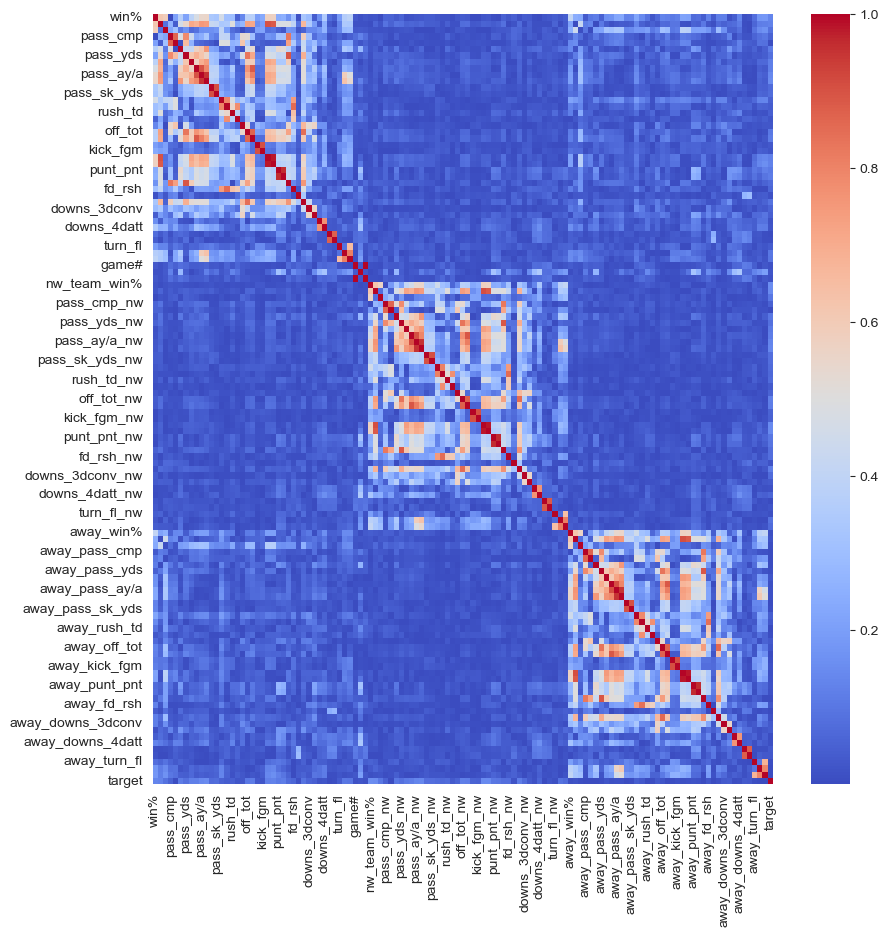

,ftr1,ftr2
0,pass_att,pass_cmp
1,pass_ay/a,pass_y/a
2,pass_rate,pass_ay/a
3,pass_sk_yds,pass_sk
4,off_tot,pass_yds
5,off_y/p,pass_y/a
6,off_y/p,pass_ay/a
7,off_y/p,off_tot
8,kick_fgm,kick_fga
9,kick_xpa,pts


In [22]:
#correlation matrix
numeric_data = merged.select_dtypes(include=['number'])
numeric_data['target'] = merged['target'].astype(bool)
corr_matrix = numeric_data.corr().abs()

#heatmap due to large number of features
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.show()

#display the pairs with high coorelation coef
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_ftrs = [
    (column,idx)
    for column in upper.columns
    for idx in upper.index
    if upper.loc[idx,column] > .8
]

pd.DataFrame(high_corr_ftrs, columns=['ftr1', 'ftr2']).head(10)

Analysis: we expect the features closest to the main diagonal to have the highest coorelation, like pass_attempts and pass_completions

Now we will look at a some decision stumps to look at variable importance

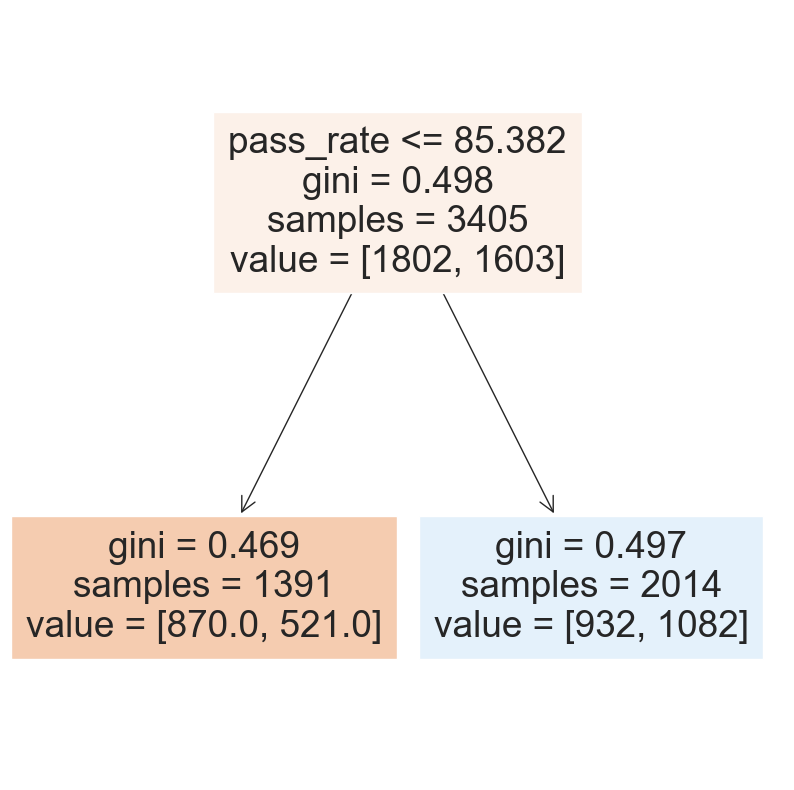

In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
stump = DecisionTreeClassifier(
    max_depth = 1,
    random_state = 22
)

stump.fit(numeric_data.drop('target', axis=1), numeric_data['target'])

plt.figure(figsize=(10,10))
plot_tree(stump,
          feature_names=numeric_data.columns,
          filled=True)
plt.show()

This stump has pass_rate as our most important variable. Looking into that, pass_rate is the 'passer rating', a score used by the NFL. Because of the nature of our project, I want to keep human scoring out of the model as much as possible until we reevaluate the model with the sentiment analysis feature. We will remove this column, and see what the second most important feature is.

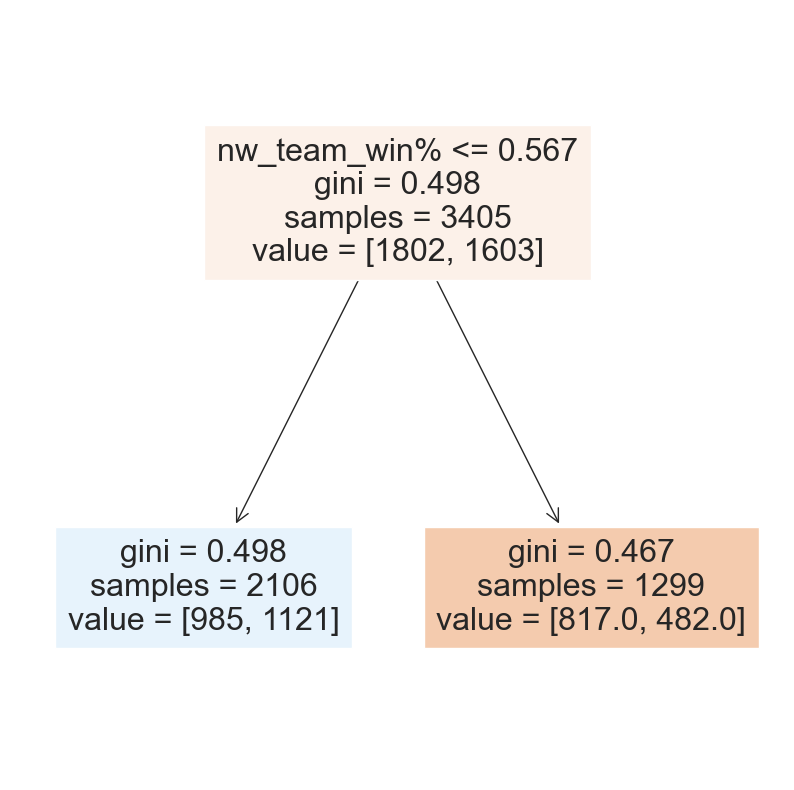

In [24]:
numeric_data = numeric_data.drop(columns = ['pass_rate', 'away_pass_rate', 'pass_rate_nw',
                                            'pass_ay/a', 'away_pass_ay/a', 'pass_ay/a_nw'], axis=1)

stump = DecisionTreeClassifier(
    max_depth = 1,
    random_state = 22
)

stump.fit(numeric_data.drop('target', axis=1), numeric_data['target'])

plt.figure(figsize=(10,10))
plot_tree(stump,
          feature_names=numeric_data.columns,
          filled=True)
plt.show()

This says our most important classifier should be our opponent's current win %. Pretty intuitive
<h3>Cluster analysis</h3>
now, we're going to try some unlabled cluster analysis and see if it leads anywhere. It is important to note that since we are using PCA, it is difficult to actually interpret what is going on with any clusters

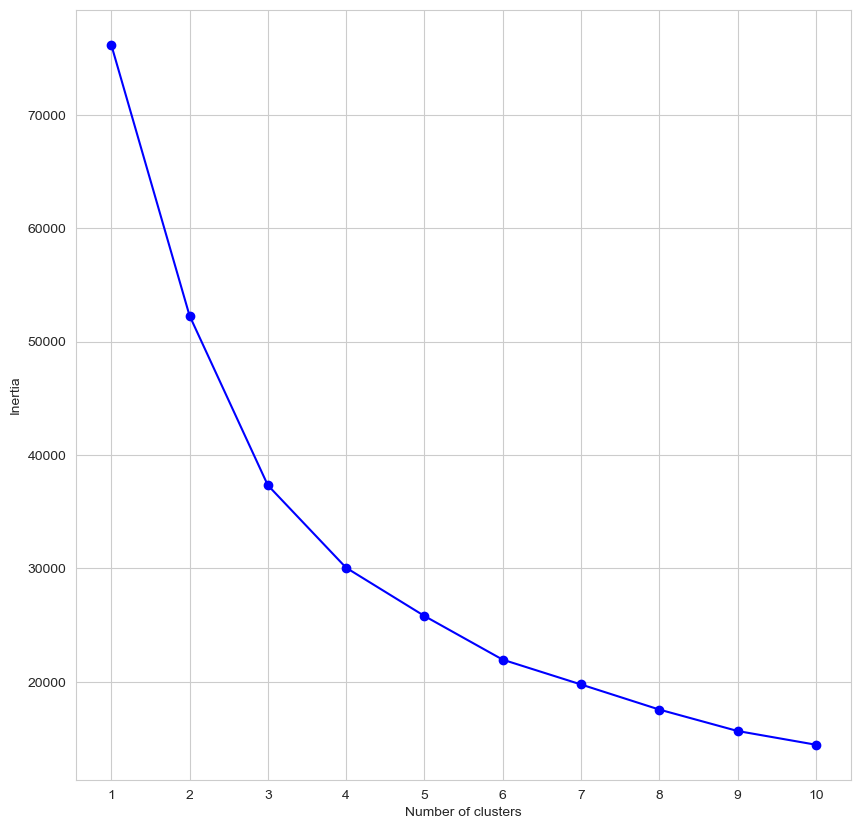

In [25]:
from  sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#scaling our data (normalizing)
scaled_numeric_data = StandardScaler().fit_transform(numeric_data)

#apply PCA
pca = PCA(n_components = 2)
pca_ftrs = pca.fit_transform(scaled_numeric_data)

#for elbow method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state=22).fit(pca_ftrs)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,10))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

3 seems to be good. Lets see our clusters

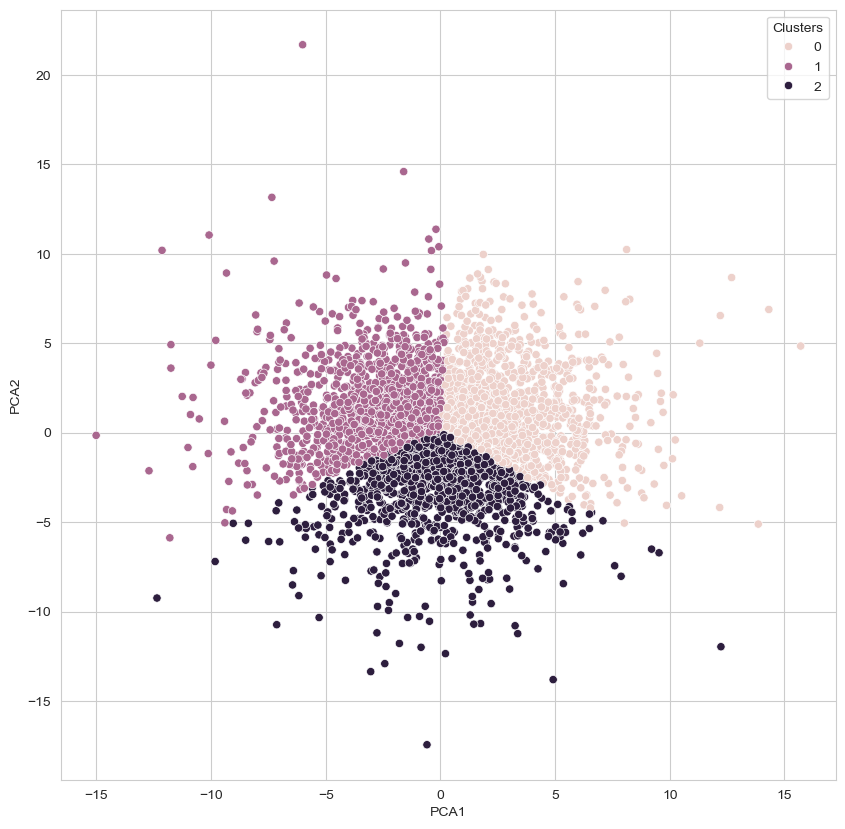

In [26]:
#kmean with k = 3
kmeans = KMeans(n_clusters = 3, random_state=22).fit(pca_ftrs)
clusters = kmeans.fit_predict(pca_ftrs)

plt.figure(figsize=(10,10))
sns.scatterplot(x=pca_ftrs[:, 0], y=pca_ftrs[:, 1], hue=clusters)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Clusters')
plt.show()

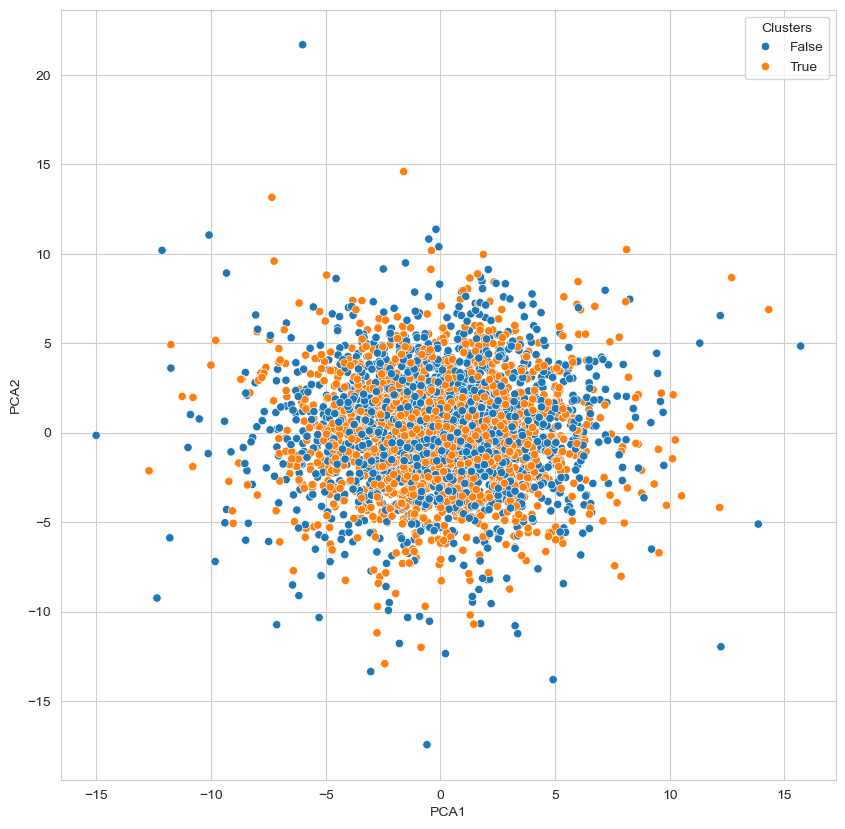

In [27]:
plt.figure(figsize=(10,10))
sns.scatterplot(x=pca_ftrs[:, 0], y=pca_ftrs[:, 1], hue=numeric_data['target'])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Clusters')
plt.show()

The clusters aren't very apparent, so not too much insight from this visualization. Let's look for the optimal number of PCA compopnenets

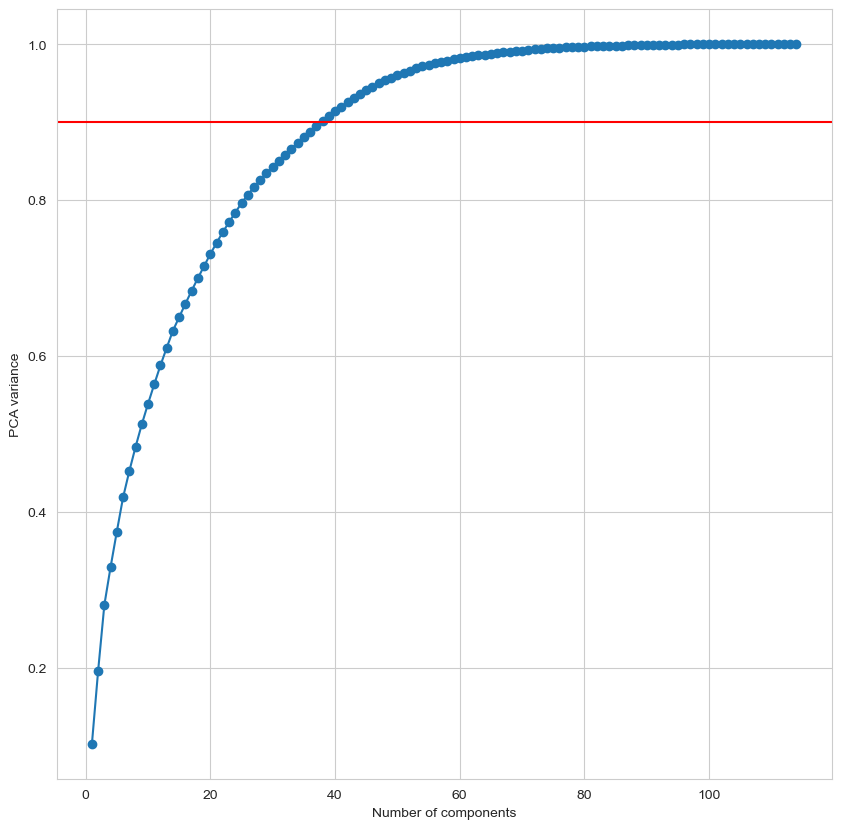

In [28]:
scaled_ftrs= StandardScaler().fit_transform(numeric_data.drop('target', axis=1))

pca = PCA()
pca = pca.fit(scaled_ftrs)

cumulative_variance = pca.explained_variance_ratio_.cumsum()

#plot
plt.figure(figsize=(10,10))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of components')
plt.ylabel('PCA variance')
plt.grid(True)
plt.axhline(y=0.9,color='r')
plt.show()

We run into a tough decision here. There isn't really a definitive 'elbow' here, but using the .9 cumulative variance threshold leads us to using ~40 components which is likely too. Our solution will be to layer PCA and variable selection to attempt to reduce the features further.

<h1>Model Building</h1>

<h2>Variable Selection</h2>
-Before we preform feature selection on our data, we want to go ahead and seperate our HOT set

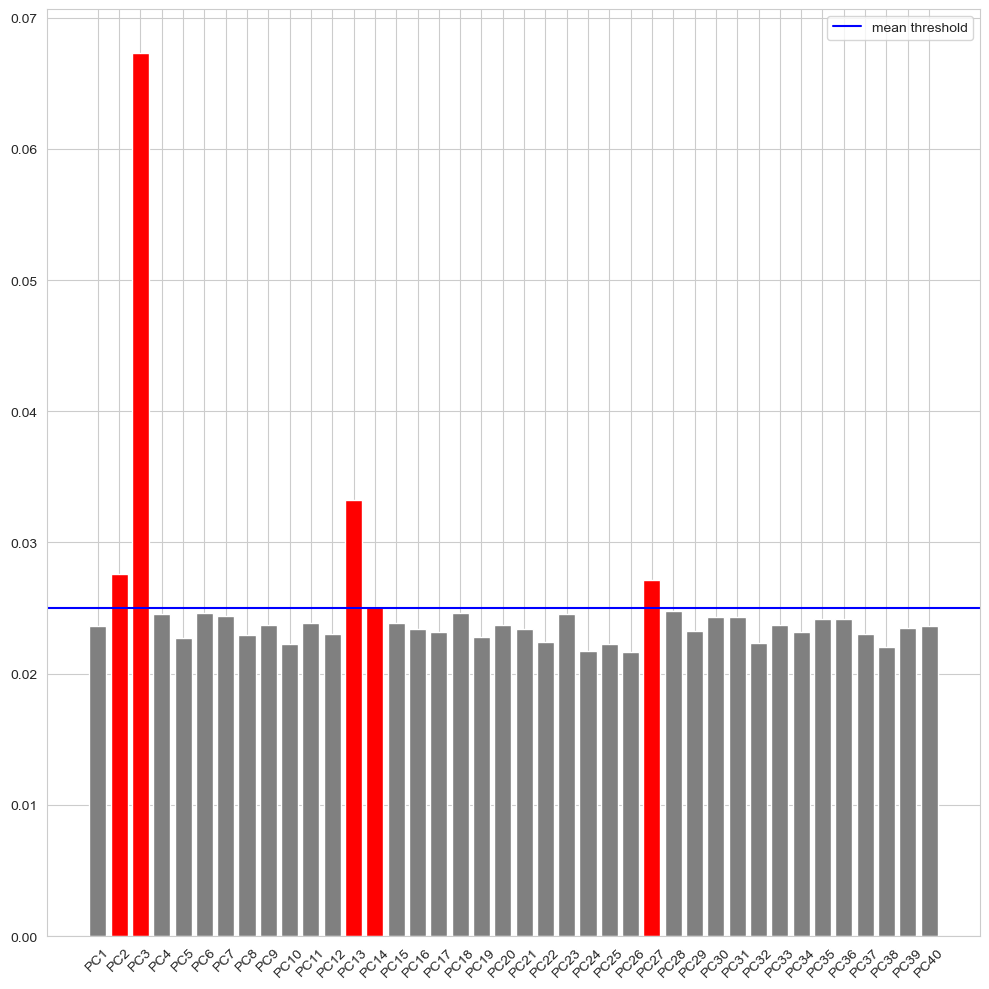

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

target = merged['target'].astype(bool)

pca = PCA(n_components = 40)
pca = pca.fit_transform(scaled_ftrs)

#Split out our HOT set
ftr_train, ftr_HOT, target_train, target_HOT = train_test_split(pca,
                                                                target,
                                                                train_size=0.9)

#using random forest to select most important PCA componenets
rf = RandomForestClassifier(n_estimators=150,
                            random_state=123)
rf.fit(ftr_train, target_train)

#extracting most important PCA componenets
selector = SelectFromModel(rf,
                           prefit=True,
                           threshold='mean')

ftr_train_selected = selector.transform(ftr_train)
ftr_HOT_selected = selector.transform(ftr_HOT)

importances = rf.feature_importances_

selected_mask = selector.get_support()

component_labels = [f'PC{i+1}' for i in range(ftr_train.shape[1])]

plt.figure(figsize=(10,10))
bars = plt.bar(component_labels,
               importances,
               align='center',
               color = ['red' if selected else 'gray' for selected in selected_mask])
plt.axhline(y=np.mean(importances),
            color = 'blue',
            label = 'mean threshold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We definitly want to investigate PC3 further!!

In [30]:
pca = PCA(n_components = 27)
pca = pca.fit(scaled_ftrs)

numeric_ftrs = numeric_data.drop('target', axis=1)

#df for loadings of each ftr
loadings = pd.DataFrame(
    pca.components_.T,
    index = numeric_ftrs.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components)]
)

#show the most highest weighted ftrs in each componenet
top_pc3 = loadings['PC3'].abs().sort_values(ascending=False).head(10)
print(top_pc3)

score_pts_nw    0.219092
off_tot_nw      0.218220
kick_xpa_nw     0.204432
fd_1std_nw      0.201004
kick_xpm_nw     0.200363
off_y/p_nw      0.200162
pass_y/a_nw     0.192822
off_tot         0.172330
pts             0.167939
pass_td_nw      0.167270
Name: PC3, dtype: float64


<h2>Discriminant Analysis</h2>
let's look at our covariance matrix now to see what type of discriminant analysis we can use

In [31]:

np.cov(ftr_train_selected.T).round(decimals=2)

array([[ 1.067e+01, -6.000e-02,  3.000e-02,  3.000e-02,  1.000e-02],
       [-6.000e-02,  9.660e+00,  1.000e-02, -1.000e-02, -0.000e+00],
       [ 3.000e-02,  1.000e-02,  2.570e+00, -3.000e-02,  2.000e-02],
       [ 3.000e-02, -1.000e-02, -3.000e-02,  2.550e+00,  2.000e-02],
       [ 1.000e-02, -0.000e+00,  2.000e-02,  2.000e-02,  1.130e+00]])

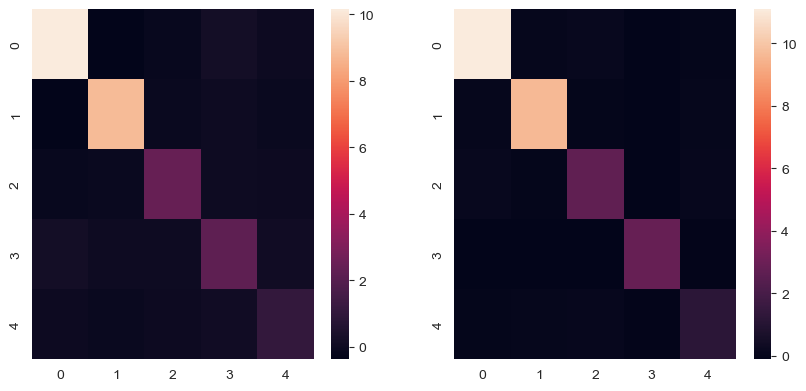

In [32]:
class_data = {label: ftr_train_selected[target_train == label] for label in [True, False]}

cov_matrices_by_class = {}
for label, data in class_data.items():
    cov_matrices_by_class[label] = np.cov(data.T)

plt.figure(figsize=(10,10))
for i, (label,matrix) in enumerate(cov_matrices_by_class.items()):
    plt.subplot(2, 2, i + 1)
    sns.heatmap(matrix)

plt.show()

In [33]:
for label, matrix in cov_matrices_by_class.items():
    print(pd.DataFrame(matrix))

           0         1         2         3         4
0  10.154481 -0.373980 -0.128319  0.174157 -0.009298
1  -0.373980  8.821844 -0.124163  0.026158 -0.101581
2  -0.128319 -0.124163  2.403103  0.031873 -0.036593
3   0.174157  0.026158  0.031873  2.203241  0.084810
4  -0.009298 -0.101581 -0.036593  0.084810  1.057242
           0         1         2         3         4
0  11.091111  0.046835  0.132611 -0.112343  0.018336
1   0.046835  9.619789 -0.019161 -0.076255  0.032606
2   0.132611 -0.019161  2.688148 -0.094857  0.065039
3  -0.112343 -0.076255 -0.094857  2.861424 -0.044312
4   0.018336  0.032606  0.065039 -0.044312  1.193299


Since it seems like we have similar covariance matricies, we will use a linear discriminant analysis

In [34]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

#try some different solvers
param_grid = {
    'solver' : ['lsqr', 'eigen'],
    'shrinkage' : [None, 'auto']
}

#gridsearch CV
lda = LinearDiscriminantAnalysis()
grid_search = GridSearchCV(lda, param_grid, cv=5, n_jobs=-1)
grid_search.fit(ftr_train_selected, target_train)

#print results
print('Best Prarms', grid_search.best_params_)
best_lda = grid_search.best_estimator_

Best Prarms {'shrinkage': 'auto', 'solver': 'lsqr'}


Get confusion matrix set up for training

In [35]:
target_train_pred = best_lda.predict(ftr_train_selected)
cm_train = confusion_matrix(target_train, target_train_pred)

pd.DataFrame(cm_train, columns=['pred0', 'pred1'])

,pred0,pred1
0,1145,477
1,716,726


In [36]:
accuracy_score(target_train, target_train_pred)

0.6106396866840731

In [37]:
f1_score(target_train, target_train_pred)

0.548960302457467

Not too bad

In [38]:
target_HOT_pred = best_lda.predict(ftr_HOT_selected)
cm_HOT = confusion_matrix(target_HOT, target_HOT_pred)
cm_HOT

array([[136,  44],
       [ 77,  84]], dtype=int64)

In [39]:
accuracy_score(target_HOT, target_HOT_pred)

0.6451612903225806

In [40]:
f1_score(target_HOT, target_HOT_pred)

0.5813148788927336

lets save our results so we can compare later

In [41]:
scores_df = pd.DataFrame({
    'Model' : ['LinearDiscriminantAnalysis'],
    'Train_accuracy' : [accuracy_score(target_train, target_train_pred)],
    'Train_f1' : [f1_score(target_train, target_train_pred)],
    'HOT_accuracy' : [accuracy_score(target_HOT, target_HOT_pred)],
    'HOT_f1' : [f1_score(target_HOT, target_HOT_pred)],
})
scores_df = scores_df.round(5)
scores_df

,Model,Train_accuracy,Train_f1,HOT_accuracy,HOT_f1
0,LinearDiscriminantAnalysis,0.61064,0.54896,0.64516,0.58131


<h2>Logistic Regression</h2>

In [42]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(ftr_train_selected, target_train)

target_train_pred = logreg.predict(ftr_train_selected)
accuracy_score(target_train, target_train_pred)

0.6099869451697127

In [43]:
f1_score(target_train, target_train_pred)

0.5512579797221179

In [44]:

pd.DataFrame(confusion_matrix(target_train, target_train_pred),
             columns=['pred0', 'pred1'])

,pred0,pred1
0,1135,487
1,708,734


Now test on our HOT set

In [45]:
target_HOT_pred = logreg.predict(ftr_HOT_selected)
accuracy_score(target_HOT, target_HOT_pred)

0.6510263929618768

In [46]:
pd.DataFrame(confusion_matrix(target_HOT, target_HOT_pred),
             columns=['pred0', 'pred1'])

,pred0,pred1
0,136,44
1,75,86


In [47]:
f1_score(target_HOT, target_HOT_pred)

0.5910652920962199

Save to our scores dataframe for final evaluation later

In [48]:
new_row = ['LogisticRegression', accuracy_score(target_train, target_train_pred),
           f1_score(target_train, target_train_pred),
           accuracy_score(target_HOT, target_HOT_pred),
           f1_score(target_HOT, target_HOT_pred)]

scores_df.loc[len(scores_df)] = new_row
scores_df = scores_df.round(5)
scores_df

,Model,Train_accuracy,Train_f1,HOT_accuracy,HOT_f1
0,LinearDiscriminantAnalysis,0.61064,0.54896,0.64516,0.58131
1,LogisticRegression,0.60999,0.55126,0.65103,0.59107


<h2>RandomForest</h2>

In [49]:
rf = RandomForestClassifier(random_state=22)

param_grid = {
    'n_estimators' : [100, 150, 200, 250, 300, 400, 500],
    'max_depth' : [None, 5, 10, 15, 20],
    'min_samples_split' : [2, 5, 10],
}

grid_search = GridSearchCV(rf,
                           param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='accuracy',)

grid_search.fit(ftr_train_selected, target_train)

best_rf = grid_search.best_estimator_
print(grid_search.best_params_)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 150}


In [50]:
target_train_pred = best_rf.predict(ftr_train_selected)
accuracy_score(target_train, target_train_pred)

0.6661227154046997

In [51]:
f1_score(target_train, target_train_pred)

0.6294820717131474

In [52]:
target_HOT_pred = best_rf.predict(ftr_HOT_selected)
accuracy_score(target_HOT, target_HOT_pred)

0.6598240469208211

In [53]:
f1_score(target_HOT, target_HOT_pred)

0.6258064516129033

In [54]:
new_row = ['RandomForestClassifier',
           accuracy_score(target_train, target_train_pred),
           f1_score(target_train, target_train_pred),
           accuracy_score(target_HOT, target_HOT_pred),
           f1_score(target_HOT, target_HOT_pred)]
scores_df.loc[len(scores_df)] = new_row
scores_df = scores_df.round(5)
scores_df

,Model,Train_accuracy,Train_f1,HOT_accuracy,HOT_f1
0,LinearDiscriminantAnalysis,0.61064,0.54896,0.64516,0.58131
1,LogisticRegression,0.60999,0.55126,0.65103,0.59107
2,RandomForestClassifier,0.66612,0.62948,0.65982,0.62581


<h2>eXtreme Gradient Boost</h2>

In [56]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier()

param_grid = {
    'n_estimators' : [100, 150, 200, 250, 300],
    'max_depth' : [None, 3, 5, 10 ],
    'learning_rate' : [0.01, 0.02, 0.05, 0.1, 0.2],
}

grid = GridSearchCV(xgb_model,
                    param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1
                    )

grid.fit(ftr_train_selected, target_train)
best_xgb = grid.best_estimator_
print(grid.best_params_)

{'learning_rate': 0.02, 'max_depth': 3, 'n_estimators': 100}


In [57]:
target_train_pred = best_xgb.predict(ftr_train_selected)
acc_train = accuracy_score(target_train, target_train_pred)
acc_train

0.643603133159269

In [58]:
f1_train = f1_score(target_train, target_train_pred)
f1_train

0.6066282420749279

In [59]:
target_HOT_pred = best_xgb.predict(ftr_HOT_selected)
acc_HOT = accuracy_score(target_HOT, target_HOT_pred)
acc_HOT

0.6539589442815249

In [60]:
f1_HOT = f1_score(target_HOT, target_HOT_pred)
f1_HOT

0.6242038216560509

In [61]:
new_row = ['XGBoost',
           acc_train,
           f1_train,
           acc_HOT,
           f1_HOT]
scores_df.loc[len(scores_df)] = new_row
scores_df = scores_df.round(5)
scores_df

,Model,Train_accuracy,Train_f1,HOT_accuracy,HOT_f1
0,LinearDiscriminantAnalysis,0.61064,0.54896,0.64516,0.58131
1,LogisticRegression,0.60999,0.55126,0.65103,0.59107
2,RandomForestClassifier,0.66612,0.62948,0.65982,0.62581
3,XGBoost,0.64360,0.60663,0.65396,0.62420


Here is the accuracies of our final base models. Now we will fine tune a sentiment analysis model and attempt to aggregate the score

<h1>Sentiment Analysis</h1>

Pull in post data

In [27]:
post_data = pd.read_json('fully_fully_filtered.json', lines=True)

In [28]:
post_data.head()

,author,created_utc,distinguished,domain,edited,gilded,hide_score,id,is_reddit_media_domain,is_self,is_video,locked,num_comments,num_crossposts,over_18,selftext,spoiler,title,url,score,upvote_ratio
0,dampsfootball,2010-07-01 02:27:31,None,dampsfootball.com,0,0.0,0.0,cku2u,0.0,False,0.0,0.0,0,0.0,False,,0.0,Lions agree to terms with needed cornerback Sp...,http://www.dampsfootball.com/news/view/Lions-a...,1,NaN
1,dampsfootball,2010-07-01 05:37:31,None,dampsfootball.com,0,0.0,0.0,ckvfb,0.0,False,0.0,0.0,0,0.0,False,,0.0,Slaton indicates he is cleared for Texans trai...,http://www.dampsfootball.com/news/view/Slaton-...,1,NaN
2,LestersLegends,2010-07-01 07:13:09,None,lesterslegends.com,0,0.0,0.0,ckw3m,0.0,False,0.0,0.0,0,0.0,False,,0.0,2010 Fantasy Football Mock Draft Round 1: Non-...,http://lesterslegends.com/2010-fantasy-footbal...,1,NaN
3,Azelea,2010-07-01 12:44:55,None,footballticketsonline.org,0,0.0,0.0,ckznr,0.0,False,0.0,0.0,0,0.0,False,,0.0,Bungels By Benson,http://www.footballticketsonline.org/bungels-b...,1,NaN
4,[deleted],2010-07-01 12:55:24,None,dampsfootball.com,0,0.0,0.0,ckzsw,0.0,False,0.0,0.0,0,0.0,False,[deleted],0.0,Chargers' WR Jackson suspended by NFL,http://www.dampsfootball.com/news/view/Source-...,1,NaN


In [29]:
post_data.shape

(1292928, 21)

In [30]:
post_data = post_data[['created_utc', 'selftext', 'title', 'upvote_ratio' ]]

In [31]:
post_data.dropna(subset=['upvote_ratio'], inplace=True)


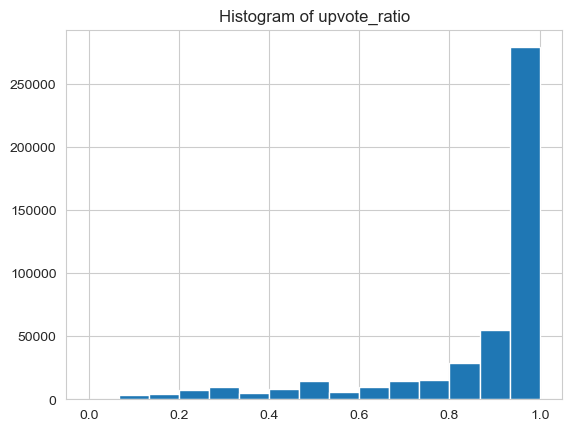

In [32]:
plt.hist(post_data['upvote_ratio'], bins=15)
plt.title('Histogram of upvote_ratio')
plt.show()

In [33]:
post_data = post_data.loc[post_data['upvote_ratio'] > .6]
post_data.shape

(402567, 4)

In [34]:
nfl_teams = pd.read_csv('nfl_team_abv.csv')
nfl_teams = nfl_teams[['Name', 'Abbreviation']]
nfl_teams['mascot'] = nfl_teams['Name'].str.split().str[1]
nfl_teams.head()

,Name,Abbreviation,mascot
0,Arizona Cardinals,CRD,Cardinals
1,Atlanta Falcons,ATL,Falcons
2,Baltimore Ravens,RAV,Ravens
3,Buffalo Bills,BUF,Bills
4,Carolina Panthers,CAR,Panthers


In [2]:
nfl_teams = nfl_teams.applymap(lambda x: x.lower() if isinstance(x, str) else x)
nfl_teams_list = set(nfl_teams[['Name', 'mascot', 'Abbreviation']].values.flatten().tolist())

post_data['team']= ''

for index, row in post_data.iterrows():
    title = set(row['title'].lower().split())
    match_found = not title.isdisjoint(nfl_teams_list)
    if match_found:
        post_data.at[index, 'team'] = title & nfl_teams_list
    else:
        post_data.at[index, 'team'] = 'n/a'

post_data.head()

In [36]:
post_data['team'].value_counts()

team
n/a                                          303785
{was}                                         18471
{cowboys}                                      3607
{eagles}                                       3587
{bills}                                        3454
                                              ...  
{steelers, ravens, jaguars, colts}                1
{lions, browns, jaguars, cardinals}               1
{lions, bengals, jaguars, colts, broncos}         1
{lions, york, was}                                1
{york, commanders, panthers}                      1
Name: count, Length: 1863, dtype: int64

In [37]:
count = post_data['team'].apply(lambda x: len(x)>1).sum()
print(count)
post_data.shape

321815


(402567, 5)

In [38]:
post_data = post_data[post_data['team'] != 'n/a']
post_data.shape

(98782, 5)

<h1>Defining our Subjects</h1>

In [81]:
import ollama
import re

def remove_think_tags(text): #Depending on what model we use, we don't want what's in these tags
  """Removes <think> tags and their content from a string."""
  return re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)

sample_posts = post_data[post_data['team'].apply(lambda x: isinstance(x, set) and len(x) > 1)]
sample_posts = sample_posts.sample(n=100)
sample_posts['team_ai'] = ''

for index, row in sample_posts.iterrows():
    response = ollama.generate(
        model = 'gemma3:4b',
        prompt = 'in a one word response, what NFL team is this post about: ' + row['title']
    )
    sample_posts.at[index,'team_ai'] = (remove_think_tags(response['response']))

KeyboardInterrupt: 

In [76]:
sample_posts.head()

,created_utc,selftext,title,upvote_ratio,team,team_ai
1240107,2024-04-18 16:06:10,[deleted],[Meirov] The Packers have signed former Eagles...,1.00,"{titans, eagles}",Packers
1264586,2024-09-22 23:24:00,#Kansas City Chiefs at Atlanta Falcons\n\n[ESP...,Post Game Thread: Kansas City Chiefs at Atlant...,0.92,"{city, falcons}",Chiefs
918380,2021-01-21 18:00:32,[deleted],"[Birkett] Per a source, Darrell Bevell spent t...",0.96,"{jaguars, lions}",Jaguars
979300,2021-09-30 23:21:47,,[Surrender_Index] JAX decided to punt to CIN f...,0.87,"{jax, cin}",Jaguars
996180,2021-11-14 16:10:17,,Today's 45-7 loss in Foxboro was Cleveland’s w...,0.98,"{was, pit}",Browns


In [78]:
multi_team_posts = post_data[post_data['team'].apply(lambda x: isinstance(x, set) and len(x) > 1)]
multi_team_posts.shape

(18030, 5)

In [1]:
multi_team_posts['team_ai'] = ''

for index, row in multi_team_posts.iterrows():
    response = ollama.generate(
        model = 'gemma3:4b',
        prompt = 'in a one word response, what NFL team is this post about: ' + row['title']
    )
    multi_team_posts.at[index,'team_ai'] = (remove_think_tags(response['response']))

In [85]:
multi_team_posts.head()

,created_utc,selftext,title,upvote_ratio,team,team_ai
832200,2020-04-29 16:06:53,"Started off as CB Troy Vincent, S Brian Dawkin...",How good was the Eagles secondary in the 2000s?,1.0,"{was, eagles}",Eagles
832336,2020-04-29 23:34:47,* HOF DE Richard Dent\n* HOF DE Dan Hampton\n*...,How did the Bears only win 1 Super Bowl in the...,1.0,"{was, bears}",Bears
832346,2020-04-30 01:23:16,,"Former Panthers and Cowboys Defensive End , Gr...",1.0,"{panthers, cowboys}",Panthers
832361,2020-04-30 04:01:44,,"For both 0-16 browns and lions teams, was it t...",1.0,"{browns, was, lions}",Browns
832463,2020-04-30 12:36:00,,"[Henderson] To many observers, Jordyn Brooks w...",1.0,"{seahawks, was}",Seahawks


In [3]:
multi_team_posts.to_csv('multi_team_posts.csv')
mtp = multi_team_posts.copy() #just in case

In [24]:
multi_team_posts = pd.read_csv('multi_team_posts.csv')

In [25]:
multi_team_posts['team'] = multi_team_posts['team_ai']
multi_team_posts.drop(columns='team_ai', inplace=True)
multi_team_posts.head()

,Unnamed: 0,created_utc,selftext,title,upvote_ratio,team
0,832200,2020-04-29 16:06:53,"Started off as CB Troy Vincent, S Brian Dawkin...",How good was the Eagles secondary in the 2000s?,1.0,Eagles
1,832336,2020-04-29 23:34:47,* HOF DE Richard Dent\n* HOF DE Dan Hampton\n*...,How did the Bears only win 1 Super Bowl in the...,1.0,Bears
2,832346,2020-04-30 01:23:16,NaN,"Former Panthers and Cowboys Defensive End , Gr...",1.0,Panthers
3,832361,2020-04-30 04:01:44,NaN,"For both 0-16 browns and lions teams, was it t...",1.0,Browns
4,832463,2020-04-30 12:36:00,NaN,"[Henderson] To many observers, Jordyn Brooks w...",1.0,Seahawks


In [4]:
pre_filtered_posts = post_data[post_data['team'].apply(lambda x: isinstance(x, set) and len(x) == 1)]
pre_filtered_posts['team_s'] = pre_filtered_posts['team'].apply(lambda s: ''.join(str(x)for x in s) if isinstance(s,set)else '')
pre_filtered_posts['team'] = pre_filtered_posts['team_s']
pre_filtered_posts.drop(columns='team_s', inplace=True)
df_sentiment = pd.concat([pre_filtered_posts,multi_team_posts], ignore_index=True)
df_sentiment.shape

In [40]:
df_sentiment.head()

,created_utc,selftext,title,upvote_ratio,team,Unnamed: 0
0,2020-04-29 14:42:26,,Chiefs Cornerback Bashaud Breeland Facing More...,1.00,was,NaN
1,2020-04-29 14:45:51,,"[Demovsky] Favre continued: ""I think that Aaro...",1.00,was,NaN
2,2020-04-29 15:40:58,,Bengals QB Joe Burrow to wear #9 and WR Tee Hi...,1.00,bengals,NaN
3,2020-04-29 16:34:49,,[Dehner Jr] I don’t really know why people are...,0.67,bengals,NaN
4,2020-04-29 16:48:09,,AFC West draft grades: Broncos load up for Loc...,1.00,broncos,NaN


In [41]:
#this is not optimal
the_dict = {'arizona cardinals':'crd',
            'atlanta falcons':'atl',
            'baltimore ravens':'rav',
            'buffalo bills':'buf',
            'carolina panthers':'car',
            'chicago bears':'chi',
            'cincinnati bengals':'cin',
            'cleveland browns':'cle',
            'dallas cowboys':'dal',
            'denver broncos':'den',
            'detroit lions':'det',
            'green bay packers':'gnb',
            'houston texans':'htx',
            'indianapolis colts':'clt',
            'jacksonville jaguars':'jax',
            'kansas city chiefs':'kan',
            'miami dolphins':'mia',
            'minnesota vikings':'min',
            'new england patriots':'new',
            'new orleans saints':'nor',
            'new york giants':'nyg',
            'new york jets':'nyj',
            'las vegas raiders':'rai',
            'philadelphia eagles':'phi',
            'pittsburgh steelers':'pit',
            'los angeles chargers':'sdg',
            'san francisco 49ers':'sfo',
            'seattle seahawks':'sea',
            'los angeles rams':'ram',
            'tampa bay buccaneers':'tam',
            'tennessee titans':'oti',
            ' washington commanders':'was',
	        ' cardinals':'crd',
            'falcons':'atl',
            'ravens':'rav',
            'bills':'buf',
            'panthers':'car',
            'bears':'chi',
            'bengals':'cin',
            'browns':'cle',
            'cowboys':'dal',
            'broncos':'den',
            'lions':'det',
            'bay':'gnb',
	        'green':'gnb',
	        'packers':'gnb',
            'texans':'htx',
            'colts':'clt',
            'jaguars':'jax',
            'chiefs':'kan',
	        ' kansas city':'kan',
            'dolphins':'mia',
            'vikings':'min',
	        'patriots':'new',
            'saints':'nor',
	        'orleans':'nor',
            'giants':'nyg',
            'jets':'nyj',
            'las':'rai',
 	        'raiders':'rai',
            'eagles':'phi',
            'steelers':'pit',
            'los':'sdg',
	        'chargers':'sdg',
            'san':'sfo',
	        '49ers':'sfo',
            'seahawks':'sea',
            'rams':'ram',
	        'buccaneers':'tam',
            'titans':'oti',
            'commanders':'was',
            'redskins':'was',    
}

In [42]:
df_sentiment['team'] = df_sentiment['team'].replace(the_dict)
df_sentiment.head()

,created_utc,selftext,title,upvote_ratio,team,Unnamed: 0
0,2020-04-29 14:42:26,,Chiefs Cornerback Bashaud Breeland Facing More...,1.00,was,NaN
1,2020-04-29 14:45:51,,"[Demovsky] Favre continued: ""I think that Aaro...",1.00,was,NaN
2,2020-04-29 15:40:58,,Bengals QB Joe Burrow to wear #9 and WR Tee Hi...,1.00,cin,NaN
3,2020-04-29 16:34:49,,[Dehner Jr] I don’t really know why people are...,0.67,cin,NaN
4,2020-04-29 16:48:09,,AFC West draft grades: Broncos load up for Loc...,1.00,den,NaN


In [43]:
sucessful_class = df_sentiment.loc[df_sentiment['team'].isin(nfl_teams['Abbreviation'])]
sucessful_class.shape

(74333, 6)

In [44]:
merged['date_nw']

0       2010-09-26
1       2010-10-17
2       2010-10-31
3       2010-11-14
4       2010-11-28
           ...    
3400    2023-10-08
3401    2023-10-29
3402    2023-11-19
3403    2023-12-10
3404    2023-12-30
Name: date_nw, Length: 3405, dtype: object

In [45]:
merged_bkup = merged.copy()

In [46]:
from datetime import timedelta

#Convert date columns
merged['datetime_nw'] = pd.to_datetime(merged['date_nw'])

successful_class = sucessful_class.copy()
successful_class['utc'] = pd.to_datetime(sucessful_class['created_utc'])

#Create time window start for each merged row
merged['start_date'] = merged['datetime_nw'] - timedelta(weeks=2)

#Step 1: Cross-merge by team (join where teams match)
temp = pd.merge(
    merged[['home_team', 'datetime_nw', 'start_date']],
    successful_class,
    left_on='home_team',
    right_on='team'
)

#Step 2: Filter to only rows within the correct 2-week window
mask = (temp['utc'] >= temp['start_date']) & (temp['utc'] <= temp['datetime_nw'])
temp = temp[mask]

#Step 3: Group by team + datetime and collect titles
title_lists = temp.groupby(['home_team', 'datetime_nw'])['title'].apply(list).reset_index()

#Step 4: Merge back to original DataFrame
merged = pd.merge(merged, title_lists, on=['home_team', 'datetime_nw'], how='left')



In [47]:
merged.head()

,win%,pts,opp_pt_avg,pass_cmp,pass_att,pass_cmp%,pass_yds,pass_td,pass_y/a,pass_ay/a,pass_rate,pass_sk,pass_sk_yds,rush_att,rush_yds,rush_td,rush_y/a,off_ply,off_tot,off_y/p,kick_fga,kick_fgm,kick_xpa,kick_xpm,punt_pnt,punt_yds,fd_pass,fd_rsh,fd_pen,fd_1std,downs_3dconv,downs_3datt,downs_4dconv,downs_4datt,pen_pen,pen_yds,turn_fl,turn_int,turn_to,away_team,home_team,home,game#,season,week,date,target,home_nw,nw_date_x,nw_game_id_x,nw_team_win%,score_pts_nw,score_ptso_nw,pass_cmp_nw,pass_att_nw,pass_cmp%_nw,pass_yds_nw,pass_td_nw,pass_y/a_nw,pass_ay/a_nw,pass_rate_nw,pass_sk_nw,pass_sk_yds_nw,rush_att_nw,rush_yds_nw,rush_td_nw,rush_y/a_nw,off_ply_nw,off_tot_nw,off_y/p_nw,kick_fga_nw,kick_fgm_nw,kick_xpa_nw,kick_xpm_nw,punt_pnt_nw,punt_yds_nw,fd_pass_nw,fd_rsh_nw,fd_pen_nw,fd_1std_nw,downs_3dconv_nw,downs_3datt_nw,downs_4dconv_nw,downs_4datt_nw,pen_pen_nw,pen_yds_nw,turn_fl_nw,turn_int_nw,turn_to_nw,home_nw,date_nw,game_id,away_win%,away_pts,away_opp_pt_avg,away_pass_cmp,away_pass_att,away_pass_cmp%,away_pass_yds,away_pass_td,away_pass_y/a,away_pass_ay/a,away_pass_rate,away_pass_sk,away_pass_sk_yds,away_rush_att,away_rush_yds,away_rush_td,away_rush_y/a,away_off_ply,away_off_tot,away_off_y/p,away_kick_fga,away_kick_fgm,away_kick_xpa,away_kick_xpm,away_punt_pnt,away_punt_yds,away_fd_pass,away_fd_rsh,away_fd_pen,away_fd_1std,away_downs_3dconv,away_downs_3datt,away_downs_4dconv,away_downs_4datt,away_pen_pen,away_pen_yds,away_turn_fl,away_turn_int,away_turn_to,nw_date_y,nw_game_id_y,datetime_nw,start_date,title
0,0.6667,16.0000,25.6667,17.3333,33.3333,51.4667,174.3333,1.0000,5.0667,3.7867,59.3333,2.0000,20.0000,20.0000,116.3333,0.6667,6.3333,55.3333,290.6667,5.2233,1.0000,0.6667,2.0000,2.0000,5.6667,259.0000,9.3333,5.0000,2.3333,16.6667,3.3333,11.3333,0.3333,0.6667,9.0000,95.0000,2.0000,1.3333,3.3333,rai,crd,True,3,2010,3,2010-09-26,False,False,2010-10-03,crd_vs_sdg_W4_2010,0.3333,24.0000,20.3333,24.3333,40.3333,62.3333,345.0000,2.3333,8.8333,8.5233,97.4333,2.3333,17.3333,26.6667,116.3333,0.6667,4.3333,69.3333,461.3333,6.7167,0.6667,0.6667,2.6667,2.6667,5.0000,207.6667,17.6667,5.3333,0.3333,23.3333,4.6667,12.3333,0.3333,1.6667,6.6667,46.0000,1.6667,1.3333,3.0000,False,2010-09-26,crd_vs_rai_W3_2010,0.3333,17.3333,25.3333,19.3333,35.6667,54.1000,204.0000,1.0000,5.7667,4.6367,64.9333,3.0000,24.0000,33.0000,147.3333,0.3333,4.5000,71.6667,351.3333,4.8833,4.3333,2.6667,1.3333,1.3333,4.0000,202.3333,11.6667,6.0000,4.3333,22.0000,4.6667,15.3333,0.3333,1.3333,11.0000,96.6667,0.3333,1.3333,1.6667,2010-10-03,htx_vs_rai_W4_2010,2010-09-26,2010-09-12,NaN
1,0.6000,17.6000,27.6000,17.0000,31.4000,54.0200,152.6000,0.6000,4.7200,2.9940,53.8600,3.8000,28.0000,19.6000,87.4000,0.4000,4.8200,54.8000,240.0000,4.3400,1.4000,1.2000,2.0000,2.0000,5.4000,236.0000,8.6000,4.2000,1.6000,14.4000,3.6000,12.2000,0.4000,0.8000,7.0000,67.8000,1.4000,1.4000,2.8000,nor,crd,True,5,2010,5,2010-10-10,False,False,2010-10-24,crd_vs_sea_W7_2010,0.6000,19.6000,19.4000,20.6000,33.4000,62.8200,206.6000,1.0000,6.2800,5.2720,76.2600,1.8000,10.2000,23.8000,85.8000,0.8000,3.6600,59.0000,292.4000,4.9920,0.8000,0.8000,2.4000,2.4000,5.8000,243.6000,10.4000,4.6000,0.8000,15.8000,5.8000,13.6000,0.2000,0.8000,5.6000,52.6000,0.6000,1.2000,1.8000,False,2010-10-17,crd_vs_nor_W5_2010,0.6000,19.8000,20.4000,28.4000,39.8000,71.5800,271.2000,1.8000,6.8800,6.6400,94.8000,1.6000,10.8000,23.2000,75.6000,0.2000,3.2200,64.6000,346.8000,5.4360,2.6000,1.8000,2.0000,2.0000,3.8000,178.4000,14.2000,5.0000,1.0000,20.2000,5.6000,12.2000,0.2000,0.4000,4.4000,38.6000,0.8000,1.0000,1.8000,2010-10-17,nor_vs_tam_W6_2010,2010-10-17,2010-10-03,NaN
2,0.4286,19.0000,28.2857,17.2857,32.8571,52.3571,167.5714,0.7143,4.9286,2.9943,51.9286,3.1429,23.8571,20.1429,92.8571,0.7143,4.8714,56.1429,260.4286,4.5743,1.1429,1.0000,2.2857,2.2857,5.1429,218.5714,9.0000,4.7143,1.5714,15.2857,3.8571,12.2857,0.4286,1.0000,6.1429,54.7143,1.5714,1.7143,3.2857,tam,crd,True,7,2010,8,2010-10-31,False,False,2010-11-07,crd_vs_min_W9_2010,0.2

In [48]:
merged.dropna(subset=['title'],inplace=True)

In [53]:
merged.head()

,win%,pts,opp_pt_avg,pass_cmp,pass_att,pass_cmp%,pass_yds,pass_td,pass_y/a,pass_ay/a,pass_rate,pass_sk,pass_sk_yds,rush_att,rush_yds,rush_td,rush_y/a,off_ply,off_tot,off_y/p,kick_fga,kick_fgm,kick_xpa,kick_xpm,punt_pnt,punt_yds,fd_pass,fd_rsh,fd_pen,fd_1std,downs_3dconv,downs_3datt,downs_4dconv,downs_4datt,pen_pen,pen_yds,turn_fl,turn_int,turn_to,away_team,home_team,home,game#,season,week,date,target,home_nw,nw_date_x,nw_game_id_x,nw_team_win%,score_pts_nw,score_ptso_nw,pass_cmp_nw,pass_att_nw,pass_cmp%_nw,pass_yds_nw,pass_td_nw,pass_y/a_nw,pass_ay/a_nw,pass_rate_nw,pass_sk_nw,pass_sk_yds_nw,rush_att_nw,rush_yds_nw,rush_td_nw,rush_y/a_nw,off_ply_nw,off_tot_nw,off_y/p_nw,kick_fga_nw,kick_fgm_nw,kick_xpa_nw,kick_xpm_nw,punt_pnt_nw,punt_yds_nw,fd_pass_nw,fd_rsh_nw,fd_pen_nw,fd_1std_nw,downs_3dconv_nw,downs_3datt_nw,downs_4dconv_nw,downs_4datt_nw,pen_pen_nw,pen_yds_nw,turn_fl_nw,turn_int_nw,turn_to_nw,home_nw,date_nw,game_id,away_win%,away_pts,away_opp_pt_avg,away_pass_cmp,away_pass_att,away_pass_cmp%,away_pass_yds,away_pass_td,away_pass_y/a,away_pass_ay/a,away_pass_rate,away_pass_sk,away_pass_sk_yds,away_rush_att,away_rush_yds,away_rush_td,away_rush_y/a,away_off_ply,away_off_tot,away_off_y/p,away_kick_fga,away_kick_fgm,away_kick_xpa,away_kick_xpm,away_punt_pnt,away_punt_yds,away_fd_pass,away_fd_rsh,away_fd_pen,away_fd_1std,away_downs_3dconv,away_downs_3datt,away_downs_4dconv,away_downs_4datt,away_pen_pen,away_pen_yds,away_turn_fl,away_turn_int,away_turn_to,nw_date_y,nw_game_id_y,datetime_nw,start_date,title
2406,0.0000,25.0000,38.0000,37.0000,54.0000,68.5000,434.0000,2.0000,8.0000,7.9400,97.3000,2.0000,16.0000,21.0000,72.0000,1.0000,3.4000,77.0000,506.0000,6.5700,2.0000,2.0000,2.0000,1.0000,2.0000,100.0000,23.0000,4.0000,1.0000,28.0000,7.0000,14.0000,0.0000,4.0000,6.0000,72.0000,1.0000,1.0000,2.0000,sea,atl,True,1,2020,1,2020-09-13,False,False,2020-09-20,atl_vs_dal_W2_2020,0.0000,17.0000,20.0000,25.0000,39.0000,64.1000,244.0000,1.0000,6.3000,6.7700,90.1000,3.0000,22.0000,27.0000,136.0000,1.0000,5.0000,69.0000,380.0000,5.5100,2.0000,1.0000,2.0000,2.0000,4.0000,156.0000,14.0000,9.0000,1.0000,24.0000,3.0000,12.0000,1.0000,3.0000,7.0000,50.0000,0.0000,0.0000,0.0000,False,2020-09-13,atl_vs_sea_W1_2020,1.000,38.0000,25.0000,31.0000,35.0000,88.6000,299.0000,4.0000,8.5000,10.8300,140.4000,3.0000,23.0000,20.0000,84.000,1.0000,4.2000,58.0000,383.0000,6.600,1.0000,1.0000,5.0000,5.0000,4.0000,191.0000,15.0000,6.0000,1.0,22.0000,3.0000,9.0000,1.0,1.0000,6.000,46.0000,0.0,0.0000,0.0000,2020-09-20,nwe_vs_sea_W2_2020,2020-09-13,2020-08-30,[[Highlight] [Quirky Research] On this date in...
2407,0.0000,30.0000,36.0000,26.6667,43.0000,61.1333,309.3333,2.3333,7.0667,7.5467,95.3000,1.6667,11.0000,26.6667,109.6667,1.0000,4.1667,71.3333,419.0000,5.8533,3.0000,2.6667,2.6667,2.0000,4.0000,163.6667,17.0000,5.0000,2.0000,24.0000,6.3333,14.6667,0.6667,2.0000,7.0000,66.0000,0.3333,0.6667,1.0000,chi,atl,True,3,2020,3,2020-09-27,False,False,2020-10-05,atl_vs_gnb_W4_2020,1.0000,40.6667,28.3333,23.6667,35.3333,66.1000,288.0000,3.0000,8.1333,9.8000,118.9667,0.6667,7.6667,31.0000,171.6667,1.3333,5.3667,67.0000,459.6667,6.8367,2.3333,2.3333,4.3333,4.3333,1.6667,68.6667,14.6667,8.6667,3.6667,27.0000,5.6667,11.3333,1.0000,1.6667,5.3333,44.3333,0.0000,0.0000,0.0000,False,2020-09-27,atl_vs_chi_W3_2020,1.000,24.6667,20.6667,22.3333,38.3333,58.9333,230.0000,3.0000,5.9667,5.8933,86.7333,2.3333,19.3333,28.3333,138.000,0.0000,4.9000,69.0000,368.0000,5.310,2.0000,1.3333,2.6667,2.6667,4.0000,187.3333,13.3333,7.3333,2.0,22.6667,5.0000,14.0000,1.0,1.6667,7.000,58.6667,0.0,1.3333,1.3333,2020-10-04,chi_vs_clt_W4_2020,2020-09-27,2020-09-13,[What is Todd Gurley wearing on his head in th...
2408,0.0000,24.4000,32.2000,25.8000,41.0000,62.4000,276.8000,1.4000,6.6400,6.6800,87.1600,2.2000,17.6000,25.8000,114.6000,1.2000,4.5000,69.0000,391.4000,5.6580,2.6000,2.4000,2.2000,1.6000,3.6000,150.4000,15.4000,6.6000,1.4000,23.4000,5.6000,13.8000,1.0000,2.2000,5.4000,52.2000,0.2000,0.6000,0.8000

<h1>Remaking the Model</h1>

In [55]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.nn.functional import softmax
import torch

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

title = merged.at[2406,'title']

inputs = tokenizer(title, padding=True, return_tensors='pt')
outputs = model(**inputs)

probs = softmax(outputs.logits, dim=1)
print(probs)

tensor([[0.0046, 0.9954],
        [0.0060, 0.9940],
        [0.7677, 0.2323],
        [0.2418, 0.7582],
        [0.8295, 0.1705],
        [0.8295, 0.1705],
        [0.9921, 0.0079],
        [0.9978, 0.0022],
        [0.9296, 0.0704],
        [0.9820, 0.0180],
        [0.0121, 0.9879],
        [0.0012, 0.9988],
        [0.9880, 0.0120]], grad_fn=<SoftmaxBackward0>)


In [ ]:
merged.reset_index(inplace=True)

In [59]:

for index, row in merged.iterrows():
    inputs = tokenizer(row['title'], padding=True, return_tensors='pt')
    outputs = model(**inputs)
    probs = softmax(outputs.logits, dim=1)
    avg_per_class = probs.mean(dim=0)
    merged.at[index, 'neg_avg'] = avg_per_class[0].item()
    merged.at[index, 'pos_avg'] = avg_per_class[1].item()

In [60]:
merged.head()

,level_0,index,win%,pts,opp_pt_avg,pass_cmp,pass_att,pass_cmp%,pass_yds,pass_td,pass_y/a,pass_ay/a,pass_rate,pass_sk,pass_sk_yds,rush_att,rush_yds,rush_td,rush_y/a,off_ply,off_tot,off_y/p,kick_fga,kick_fgm,kick_xpa,kick_xpm,punt_pnt,punt_yds,fd_pass,fd_rsh,fd_pen,fd_1std,downs_3dconv,downs_3datt,downs_4dconv,downs_4datt,pen_pen,pen_yds,turn_fl,turn_int,turn_to,away_team,home_team,home,game#,season,week,date,target,home_nw,nw_date_x,nw_game_id_x,nw_team_win%,score_pts_nw,score_ptso_nw,pass_cmp_nw,pass_att_nw,pass_cmp%_nw,pass_yds_nw,pass_td_nw,pass_y/a_nw,pass_ay/a_nw,pass_rate_nw,pass_sk_nw,pass_sk_yds_nw,rush_att_nw,rush_yds_nw,rush_td_nw,rush_y/a_nw,off_ply_nw,off_tot_nw,off_y/p_nw,kick_fga_nw,kick_fgm_nw,kick_xpa_nw,kick_xpm_nw,punt_pnt_nw,punt_yds_nw,fd_pass_nw,fd_rsh_nw,fd_pen_nw,fd_1std_nw,downs_3dconv_nw,downs_3datt_nw,downs_4dconv_nw,downs_4datt_nw,pen_pen_nw,pen_yds_nw,turn_fl_nw,turn_int_nw,turn_to_nw,home_nw,date_nw,game_id,away_win%,away_pts,away_opp_pt_avg,away_pass_cmp,away_pass_att,away_pass_cmp%,away_pass_yds,away_pass_td,away_pass_y/a,away_pass_ay/a,away_pass_rate,away_pass_sk,away_pass_sk_yds,away_rush_att,away_rush_yds,away_rush_td,away_rush_y/a,away_off_ply,away_off_tot,away_off_y/p,away_kick_fga,away_kick_fgm,away_kick_xpa,away_kick_xpm,away_punt_pnt,away_punt_yds,away_fd_pass,away_fd_rsh,away_fd_pen,away_fd_1std,away_downs_3dconv,away_downs_3datt,away_downs_4dconv,away_downs_4datt,away_pen_pen,away_pen_yds,away_turn_fl,away_turn_int,away_turn_to,nw_date_y,nw_game_id_y,datetime_nw,start_date,title,neg_avg,pos_avg
0,0,2406,0.0000,25.0000,38.0000,37.0000,54.0000,68.5000,434.0000,2.0000,8.0000,7.9400,97.3000,2.0000,16.0000,21.0000,72.0000,1.0000,3.4000,77.0000,506.0000,6.5700,2.0000,2.0000,2.0000,1.0000,2.0000,100.0000,23.0000,4.0000,1.0000,28.0000,7.0000,14.0000,0.0000,4.0000,6.0000,72.0000,1.0000,1.0000,2.0000,sea,atl,True,1,2020,1,2020-09-13,False,False,2020-09-20,atl_vs_dal_W2_2020,0.0000,17.0000,20.0000,25.0000,39.0000,64.1000,244.0000,1.0000,6.3000,6.7700,90.1000,3.0000,22.0000,27.0000,136.0000,1.0000,5.0000,69.0000,380.0000,5.5100,2.0000,1.0000,2.0000,2.0000,4.0000,156.0000,14.0000,9.0000,1.0000,24.0000,3.0000,12.0000,1.0000,3.0000,7.0000,50.0000,0.0000,0.0000,0.0000,False,2020-09-13,atl_vs_sea_W1_2020,1.000,38.0000,25.0000,31.0000,35.0000,88.6000,299.0000,4.0000,8.5000,10.8300,140.4000,3.0000,23.0000,20.0000,84.000,1.0000,4.2000,58.0000,383.0000,6.600,1.0000,1.0000,5.0000,5.0000,4.0000,191.0000,15.0000,6.0000,1.0,22.0000,3.0000,9.0000,1.0,1.0000,6.000,46.0000,0.0,0.0000,0.0000,2020-09-20,nwe_vs_sea_W2_2020,2020-09-13,2020-08-30,[[Highlight] [Quirky Research] On this date in...,0.583226,0.416774
1,1,2407,0.0000,30.0000,36.0000,26.6667,43.0000,61.1333,309.3333,2.3333,7.0667,7.5467,95.3000,1.6667,11.0000,26.6667,109.6667,1.0000,4.1667,71.3333,419.0000,5.8533,3.0000,2.6667,2.6667,2.0000,4.0000,163.6667,17.0000,5.0000,2.0000,24.0000,6.3333,14.6667,0.6667,2.0000,7.0000,66.0000,0.3333,0.6667,1.0000,chi,atl,True,3,2020,3,2020-09-27,False,False,2020-10-05,atl_vs_gnb_W4_2020,1.0000,40.6667,28.3333,23.6667,35.3333,66.1000,288.0000,3.0000,8.1333,9.8000,118.9667,0.6667,7.6667,31.0000,171.6667,1.3333,5.3667,67.0000,459.6667,6.8367,2.3333,2.3333,4.3333,4.3333,1.6667,68.6667,14.6667,8.6667,3.6667,27.0000,5.6667,11.3333,1.0000,1.6667,5.3333,44.3333,0.0000,0.0000,0.0000,False,2020-09-27,atl_vs_chi_W3_2020,1.000,24.6667,20.6667,22.3333,38.3333,58.9333,230.0000,3.0000,5.9667,5.8933,86.7333,2.3333,19.3333,28.3333,138.000,0.0000,4.9000,69.0000,368.0000,5.310,2.0000,1.3333,2.6667,2.6667,4.0000,187.3333,13.3333,7.3333,2.0,22.6667,5.0000,14.0000,1.0,1.6667,7.000,58.6667,0.0,1.3333,1.3333,2020-10-04,chi_vs_clt_W4_2020,2020-09-27,2020-09-13,[What is Todd Gurley wearing on his head in th...,0.594392,0.405608
2,2,2408,0.0000,24.4000,32.2000,25.8000,41.0000,62.4000,276.8000,1.4000,6.6400,6.6800,87.1600,2.2000,17.6000,25.8000,114.6000,1.2000,4.5000,69.0000,391.4000,5.6580,2.6000,2.4000,2.2000,1.6000,3.6000,150.4000,15.4000,6.6000,1

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#scale our data and such
numeric_data = merged.select_dtypes(include=['number'])
numeric_data['target'] = merged['target'].astype(bool)
neg_avg_sa = merged['neg_avg']
pos_avg_sa = merged['pos_avg']
scaled_ftrs= StandardScaler().fit_transform(numeric_data.drop(columns=[
                                                              'target',
                                                              'neg_avg',
                                                              'pos_avg'],
                                                              axis=1))

In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from  sklearn.decomposition import PCA

target = merged['target'].astype(bool)


pca = PCA(n_components = 40)
pca = pca.fit_transform(scaled_ftrs)

#we force our Sentiment Analysis scores to be features
pca = np.hstack([pca,neg_avg_sa.to_numpy().reshape(753,1)])
pca = np.hstack([pca,pos_avg_sa.to_numpy().reshape(753,1)])

#Split out our HOT set
ftr_train, ftr_HOT, target_train, target_HOT = train_test_split(pca,
                                                                target,
                                                                train_size=0.9)

#using random forest to select most important PCA componenets
rf = RandomForestClassifier(n_estimators=150,
                            random_state=123)
rf.fit(ftr_train, target_train)

#extracting most important PCA componenets
selector = SelectFromModel(rf,
                           prefit=True,
                           threshold='mean')

ftr_train_selected = selector.transform(ftr_train)
ftr_HOT_selected = selector.transform(ftr_HOT)




<h1>Random Forest with SA</h1>

In [94]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=22)

param_grid = {
    'n_estimators' : [100, 150, 200, 250, 300, 400, 500],
    'max_depth' : [None, 5, 10, 15, 20],
    'min_samples_split' : [2, 5, 10],
}

grid_search = GridSearchCV(rf,
                           param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='accuracy',)

grid_search.fit(ftr_train_selected, target_train)

best_rf = grid_search.best_estimator_
print(grid_search.best_params_)

{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 150}


In [95]:
target_train_pred = best_rf.predict(ftr_train_selected)
accuracy_score(target_train, target_train_pred)

0.8537666174298375

In [96]:

f1_score(target_train, target_train_pred)

0.8537666174298375

In [97]:

target_HOT_pred = best_rf.predict(ftr_HOT_selected)
accuracy_score(target_HOT, target_HOT_pred)

0.6052631578947368

In [98]:

f1_score(target_HOT, target_HOT_pred)

0.5833333333333334

<h1>xgb_with_sa</h1>

In [112]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier()

param_grid = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [None, 3, 5, 10],
    'learning_rate': [0.01, 0.02, 0.05, 0.1, 0.2],
}

grid = GridSearchCV(xgb_model,
                    param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1
                    )

grid.fit(ftr_train_selected, target_train)
best_xgb = grid.best_estimator_
print(grid.best_params_)
target_train_pred = best_xgb.predict(ftr_train_selected)
acc_train = accuracy_score(target_train, target_train_pred)
acc_train
f1_train = f1_score(target_train, target_train_pred)
f1_train
target_HOT_pred = best_xgb.predict(ftr_HOT_selected)
acc_HOT = accuracy_score(target_HOT, target_HOT_pred)
acc_HOT
f1_HOT = f1_score(target_HOT, target_HOT_pred)
f1_HOT
new_row = ['XGBoost',
           acc_train,
           f1_train,
           acc_HOT,
           f1_HOT]
new_row

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}


['XGBoost',
 0.8626292466765141,
 0.8614008941877794,
 0.618421052631579,
 0.5915492957746479]

<center><h1>CONCLUSION</h1></center>

While the addition of aggregate sentiment analysis dramatically improved training accuracy, it provided no increase to testing scores. Improvements could be made to the Sentiment Analysis methodology, as this was a simplistic and untested approach. The drastic improvement in accuracy will be investigated in the future.